# Intuitions: what capacity limits do to the accumulation process itself

Notebooks 01-02 (and the underlying memo, `IB_memo_v6.md`) establish *what*
a capacity-limited representation looks like, in aggregate: it is a
quantized code, a handful of discrete states whose boundaries sit where
`(occupancy) x (usefulness)` peaks, and the resulting predictiveness-vs-
capacity frontier is a staircase, not a smooth curve.

This notebook asks a more concrete question: watching a single decision
unfold in real time, moment by moment, **what does the capacity-limited
process actually look like while it's running**, compared to the normative
(unconstrained) process on the exact same sequence of evidence? The claim
worth building real intuition for is that capacity does not add *noise* to
the accumulation process — it does not blur a graded trajectory into a
fuzzier version of itself. It **coarsens the trajectory into a staircase**:
a small number of discrete states, held for a while, then jumped between.

Three tasks, in order of increasing generality, all already covered by this
project's code:

1. **Beads task** (`ib_core.py`) — one signal-to-noise ratio (SNR), one
   hazard rate `h`, evidence arrives as discrete draws (bead colours).
2. **Triangles task** — the same switching-source structure, but evidence
   is continuous-valued (a star's position), and both SNR and `h` can
   change block to block.
3. **A DDM-like bounded accumulator** (`absorbing_ib.py`,
   `ib_optimal_placement*.py`) — a stationary source with an absorbing
   decision bound instead of a stabilizing one, i.e. the process
   terminates in a choice rather than tracking forever. Covered in three
   steps: one SNR with equal (symmetric) priors, one SNR with an
   asymmetric prior, and a range (mixture) of SNRs with a symmetric prior.

**Glossary** (used throughout): `h` = hazard rate, the probability the
hidden source switches from one moment to the next. `d'` (d-prime) =
discriminability, how separable two sources are from a single observation
— the continuous-evidence analogue of the bead task's `p` (majority-colour
probability). `LLR` = log-likelihood ratio, how strongly one observation
favours one hypothesis over the other. `L_t` = the normative belief (log-
posterior-odds) at time `t`. Capacity = how many distinguishable internal
states a representation can hold, in bits (`log2(k)` for a `k`-state code)
or as the raw state count `k`.

**Shared conventions across every figure below:**
- **Blue** = the normative process (no capacity limit): the exact Bayesian
  belief for the tracking tasks, or the continuous DDM for the bounded-
  accumulator task.
- **Warm colours (red -> orange -> yellow)** = capacity-limited processes,
  from the most severe limit (few states) to the mildest.
- **Light shading** = the true hidden state (which jar / which triangle /
  which side is correct), so the eye can compare belief to ground truth
  directly.
- **Dotted gray lines** = a reference criterion or bound (e.g. `p=0.5`, or
  the decision bounds `0`/`a`).

All of this reuses the project's existing, validated exact machinery
(`ib_core.py`, `absorbing_ib.py`, `ib_optimal_placement*.py`). The one new
piece is a small module, `intuitions.py`, added alongside them: it adds
*single-trial trajectory* simulators (the existing modules compute exact
summary statistics — stationary distributions, frontiers, absorption
probabilities — but none of them return a moment-to-moment path, which is
what a picture of "the process unfolding" needs).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "utilities"))

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from ib_core import fsm_stationary, fsm_scores, optimal_recursive_fsm, optimise_recursive
from absorbing_ib import (
    walk_params_from_ddm, capacity_frontier, ddm_analytic_accuracy, ddm_analytic_mean_rt,
)
from ib_optimal_placement import ib_optimal_chain_fixed_start
from ib_optimal_placement_unknown_drift import (
    ib_optimal_chain_unknown_drift_fixed_start, ib_optimal_chain_snr_range_fixed_start, snr_branches,
)
from intuitions import (
    simulate_switching_sequence, bead_levels, emit_discrete, llr_table,
    discretize_gaussian, emit_continuous, bin_index,
    glaze_psi, glaze_trajectory,
    get_optimal_fsm, canonicalize_fsm, simulate_ladder_path,
    simulate_ddm_path, simulate_discrete_chain_path, simulate_nonuniform_chain_path,
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
# Larger default text everywhere (~12pt) so figures are readable without zooming.
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.titlesize": 13,
})

# shared colour conventions
NORM_COLOR = "#2b6cb0"   # normative / full capacity
LADDER_COLORS = {2: "#c53030", 4: "#dd6b20", 8: "#d69e2e"}   # capacity-limited, low -> high k
SHADE_COLOR = "#ebf4ff"  # true hidden state

---

# Part 1 — The beads task: one SNR, one hazard rate

A jar draws coloured beads one at a time; the jar's majority colour has
probability `p` (the manuscript's value, `p=0.8`, is used throughout). The
jar switches to the other jar with probability `h` on every draw — the
observer never sees the switch, only the beads, and has to track which jar
is currently active.

**The normative solution** (Glaze et al. 2015) updates a log-posterior-odds
belief `L_t` (positive = "probably jar 1") by

```
L_t = psi(L_{t-1}) + LLR(bead_t)
```

`LLR(bead_t) = log[p(bead|jar 1) / p(bead|jar 0)]` is a fixed number per
bead colour (`+-log(p/(1-p)) = +-log4` here). `psi` is a nonlinear discount
that leaks old evidence back toward zero — it is what makes the belief
track a *switching* source rather than integrate forever — and it has a
fixed point: no matter how much evidence piles up in one direction, `L_t`
never exceeds `+-log[(1-h)/h]`. This is the **stabilizing bound**, and it
exists precisely because the source can switch; a hazard-free (`h=0`)
process would have no such ceiling.

`psi` is what makes this task different from the DDM in Part 3: the belief
here is *self-correcting*, not accumulate-to-bound. Plotted below at
`h=0.01`.

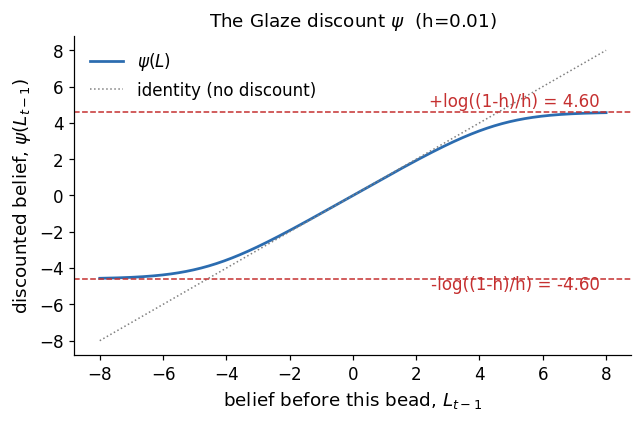

In [2]:
h = 0.01
p_bead = 0.8
L_grid = np.linspace(-8, 8, 400)
psiL = glaze_psi(L_grid, h)
bound = np.log((1 - h) / h)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(L_grid, psiL, color=NORM_COLOR, lw=1.8, label=r"$\psi(L)$")
ax.plot(L_grid, L_grid, color="gray", ls=":", lw=1, label="identity (no discount)")
ax.axhline(bound, color="#c53030", ls="--", lw=1)
ax.axhline(-bound, color="#c53030", ls="--", lw=1)
ax.text(7.8, bound + 0.3, f"+log((1-h)/h) = {bound:.2f}", fontsize=11, color="#c53030", ha="right")
ax.text(7.8, -bound - 0.6, f"-log((1-h)/h) = {-bound:.2f}", fontsize=11, color="#c53030", ha="right")
ax.set_xlabel(r"belief before this bead, $L_{t-1}$")
ax.set_ylabel(r"discounted belief, $\psi(L_{t-1})$")
ax.set_title(f"The Glaze discount $\\psi$  (h={h})")
ax.legend(frameon=False, fontsize=11, loc="upper left")
fig.tight_layout()
plt.show()

## The capacity-limited "mental model": a bounded ladder

Before looking at numbers, it's worth being precise about what the "ladder"
actually is, because the natural first guess about how it works is wrong.

**The wrong intuition:** chop the belief scale (`L`, the normative log-odds)
into `k` contiguous ranges, track which range the true, continuous `L`
currently falls in, and move to a neighboring range only once enough
evidence has piled up to cross that range's boundary. Under this picture, a
ladder with wide ranges (few, coarse rungs) should be *hard to move* — you'd
need a long run of evidence to cross a wide boundary — while a ladder with
many narrow rungs should move on almost every bead.

**What it actually is: a bounded vote tally, plus a lookup table.** The
state `r` is not a range on the belief axis at all — it's a counter that
starts somewhere in `{0, ..., k-1}`, adds 1 for every bead favouring jar 1,
subtracts 1 for every bead favouring jar 0, and *clips* rather than
overflows once it hits either end. That's it: at low hazard (checked
explicitly below) this vote-counting rule literally **is** the optimal
transition rule, not an approximation to it.

Two different tables are involved, and it matters that they're not the same
table:
- the raw bead-colour table (`P`/`llr_bead`) is a genuine **likelihood**,
  `p(bead colour | jar)` — two numbers, fixed by the task. It decides only
  which *direction* a given bead pushes the tally.
- the rung table `q` is **not** a likelihood — it's the exact **posterior**
  `p(jar=1 | rung)`, one number per rung, decided once in advance rather
  than recomputed on the fly. It has to be a posterior rather than a simple
  per-bead lookup because how often a given rung is visited while jar=1 is
  actually true depends on the *whole* process — how often the jar
  switches, how reliable each bead is — not on the tally value alone; it's
  read off the exact stationary distribution of the tally-plus-jar process
  (`fsm_stationary`, the same machinery notebooks 01-02 use for exact
  frontiers).

The figure below shows both pieces together for a concrete `k=4` example:
the lookup table on the left, and a real bead-by-bead tally trajectory
(with each bead marked by which way it pushed) on the right.

That transition rule — how far to move for a bead favouring jar 1 versus
jar 0, from each rung — is *found* by `get_optimal_fsm(k, P, H)`, not
assumed: it searches over every one of the `k**(2k)` possible `k`-state
machines (a real exhaustive search up to about `k=4`; discrete
hill-climbing, validated against that exhaustive search everywhere they
can be compared, beyond that), handed the actual `P` (bead reliability)
and `H` (hazard rate) for this task, and keeps whichever machine carries
the most information about the jar.

An earlier version of this notebook skipped the search and used the
vote-tally rule unconditionally at every hazard rate, on the (unstated)
assumption that it would always be optimal. It happens to equal the true
optimum at `k=4`, `h=0.01` (matching the memo's own exhaustive-search
result at that specific hazard rate), which is exactly why it looked right
at first. But comparing it against genuine exhaustive search at other
hazard rates (further down) showed it losing up to 40% of the achievable
predictive information once `h` grew — a real, measurable cost of assuming
the rule instead of solving for it. Every machine in this notebook from
here on is the actual solved optimum for its own `(k, h)`.

In [3]:
P_bead = bead_levels(p_bead)          # (2, 2): [jar, bead-colour] level probabilities
llr_bead = llr_table(P_bead)          # LLR of each bead colour
H_bead = np.array([[1 - h, h], [h, 1 - h]])

opt4 = get_optimal_fsm(4, P_bead, H_bead)
f4, q4 = opt4["f"], opt4["q"]

print(f"Found by {opt4['method']} search over every one of the 65,536 possible 4-state machines:")
print("Belief reported at each rung, p(jar=1 | rung):")
for r, qr in enumerate(q4):
    print(f"  rung {r}: {qr:.2f}")
print("(monotonically more confident in jar=1 the higher the rung -- and at this h, the optimal wiring")
print(" turns out to be the simple vote-tally rule, matching the memo's own h=0.01 result. That will")
print(" NOT stay true at every h -- see further down.)")

print(f"\nThis ladder uses {opt4['cap']:.2f} bits of memory and retains {opt4['I_filter']:.2f} bits of "
      f"predictive\ninformation about the jar -- {opt4['I_filter'] / 0.7997:.0%} of the 0.80-bit ceiling an "
      "observer with\nunlimited memory could achieve.")

Found by exhaustive search over every one of the 65,536 possible 4-state machines:
Belief reported at each rung, p(jar=1 | rung):
  rung 0: 0.02
  rung 1: 0.23
  rung 2: 0.77
  rung 3: 0.98
(monotonically more confident in jar=1 the higher the rung -- and at this h, the optimal wiring
 turns out to be the simple vote-tally rule, matching the memo's own h=0.01 result. That will
 NOT stay true at every h -- see further down.)

This ladder uses 1.81 bits of memory and retains 0.69 bits of predictive
information about the jar -- 87% of the 0.80-bit ceiling an observer with
unlimited memory could achieve.


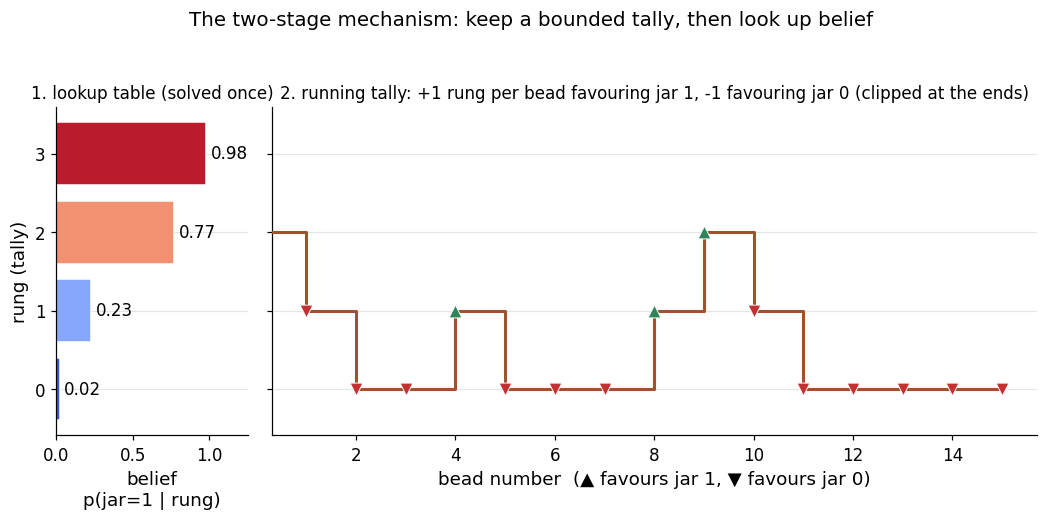

Reading the right panel: every triangle is one bead. Its direction (up/down) is set by the
likelihood table (which colour favours which jar); the height it lands on is the clipped vote
tally. Reading across from that height to the left panel gives the belief -- e.g. beads 2-3 both
land the tally on rung 0, and rung 0 always means p(jar=1)=0.02, regardless of how it got there.


In [4]:
demo_T = 15
rng_demo = np.random.default_rng(42)
y_demo = simulate_switching_sequence(demo_T, h, rng_demo)
lev_demo = emit_discrete(y_demo, P_bead, rng_demo)
r_demo = simulate_ladder_path(f4, lev_demo, r0=2)

fig, (ax_dec, ax_traj) = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True,
                                       gridspec_kw={"width_ratios": [1, 4], "wspace": 0.05})
bar_colors = plt.cm.coolwarm(q4)
for r in range(4):
    ax_dec.axhline(r, color="#e5e5e5", lw=0.8, zorder=0)
    ax_traj.axhline(r, color="#e5e5e5", lw=0.8, zorder=0)
ax_dec.barh(np.arange(4), q4, color=bar_colors, edgecolor="white", zorder=2)
for r, qr in enumerate(q4):
    ax_dec.text(qr + 0.03, r, f"{qr:.2f}", va="center", fontsize=11)
ax_dec.set_xlim(0, 1.25)
ax_dec.set_xlabel("belief\np(jar=1 | rung)")
ax_dec.set_ylabel("rung (tally)")
ax_dec.set_yticks(np.arange(4))
ax_dec.set_title("1. lookup table (solved once)", fontsize=11)

tt = np.arange(1, demo_T + 1)
ax_traj.step([0, *tt], [2, *r_demo], where="post", color="#a0522d", lw=2, zorder=3)
for t, lev in zip(tt, lev_demo):
    fav1 = llr_bead[lev] > 0
    marker = "^" if fav1 else "v"
    mcol = "#2f855a" if fav1 else "#c53030"
    y = r_demo[t - 1]
    ax_traj.scatter(t, y, marker=marker, color=mcol, s=70, zorder=5, edgecolor="white", lw=0.6)
ax_traj.set_xlabel("bead number  (▲ favours jar 1, ▼ favours jar 0)")
ax_traj.set_title("2. running tally: +1 rung per bead favouring jar 1, -1 favouring jar 0 (clipped at the ends)",
                   fontsize=11)
ax_traj.set_xlim(0.3, demo_T + 0.7)
fig.suptitle("The two-stage mechanism: keep a bounded tally, then look up belief", y=1.03)
fig.subplots_adjust(top=0.82)
plt.show()

print("Reading the right panel: every triangle is one bead. Its direction (up/down) is set by the")
print("likelihood table (which colour favours which jar); the height it lands on is the clipped vote")
print("tally. Reading across from that height to the left panel gives the belief -- e.g. beads 2-3 both")
print("land the tally on rung 0, and rung 0 always means p(jar=1)=0.02, regardless of how it got there.")

## A single trial, three capacities

The same bead sequence, run through the normative recursion and through
`k=2`, `4`, `8`-state ladders. Each ladder sees exactly the same beads as
the normative model — nothing about the input changes, only how much of it
can be retained.

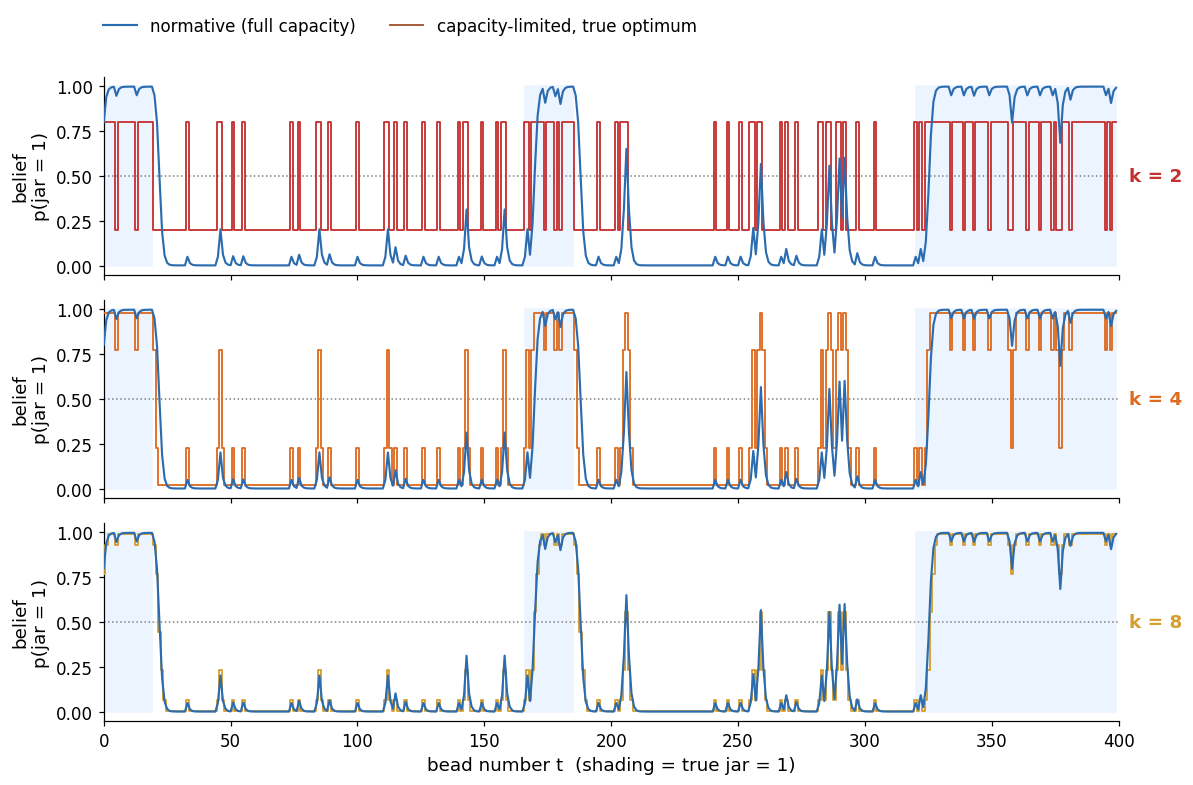

In [5]:
T = 400
rng = np.random.default_rng(3)
y_bead = simulate_switching_sequence(T, h, rng)
levels_bead = emit_discrete(y_bead, P_bead, rng)
llr_seq = llr_bead[levels_bead]
L_bead = glaze_trajectory(llr_seq, h)
sigL_bead = 1 / (1 + np.exp(-L_bead))

k_list_bead = [2, 4, 8]
ladder_belief_bead = {}
for k in k_list_bead:
    opt = get_optimal_fsm(k, P_bead, H_bead)
    fk, qk = opt["f"], opt["q"]
    rk = simulate_ladder_path(fk, levels_bead, r0=k // 2)
    ladder_belief_bead[k] = qk[rk]

fig, axes = plt.subplots(len(k_list_bead), 1, figsize=(11, 7.2), sharex=True)
for ax, k in zip(axes, k_list_bead):
    ax.fill_between(np.arange(T), 0, 1, where=(y_bead == 1), color=SHADE_COLOR, step="mid", zorder=0)
    ax.plot(sigL_bead, color=NORM_COLOR, lw=1.4, zorder=5)
    ax.step(np.arange(T), ladder_belief_bead[k], color=LADDER_COLORS[k], lw=1.2, where="mid", zorder=4)
    ax.axhline(0.5, color="gray", ls=":", lw=1)
    ax.set_xlim(0, T)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel("belief\np(jar = 1)")
    ax.text(1.01, 0.5, f"k = {k}", transform=ax.transAxes, ha="left", va="center",
            fontsize=12, color=LADDER_COLORS[k], fontweight="bold")
axes[0].plot([], [], color=NORM_COLOR, lw=1.4, label="normative (full capacity)")
axes[0].plot([], [], color="#a0522d", lw=1.2, label="capacity-limited, true optimum")
fig.legend(frameon=False, fontsize=11, loc="upper left", bbox_to_anchor=(0.08, 1.0), ncol=2)
axes[-1].set_xlabel("bead number t  (shading = true jar = 1)")
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

At `k=2` the true 2-state optimum has no way to hold a category across
beads at all — with only two states, the best possible machine (confirmed
by exhaustive search at every `h` checked in this notebook, not just this
one) is forced into the one-back rule: each new bead completely overwrites
the previous state, so the belief snaps entirely to whichever of the two
decoder values the single most recent bead favours, regardless of
everything before it. This makes `k=2` qualitatively different from the
other capacities, not just a coarser version of them: because it has no
memory of the run of evidence that came before, a single counter-evidence
bead in the middle of an otherwise one-sided streak flips it straight to
the *opposite* extreme rung — not to whichever rung happens to sit nearest
the normative belief. So `k=2` is best described as a **one-bead memory**,
not a rounding of the normative curve.

From `k=4` up, a state can survive a single dissenting bead, and the
"rounded off to the nearest rung" description starts to fit: the trace
tracks the normative curve's ups and downs and mostly lands on whichever
rung is closest to it, overshooting and lagging mainly around transitions.
By `k=8` it tracks the normative curve closely almost everywhere.

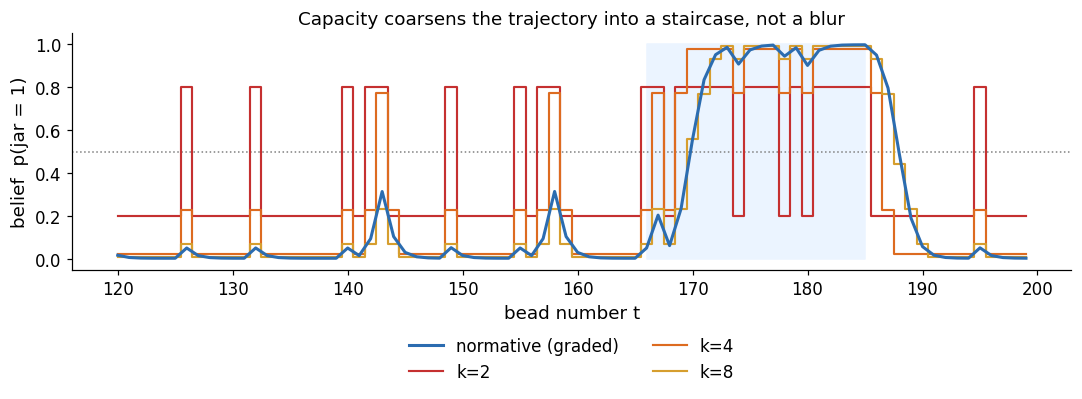

In [6]:
zoom = slice(120, 200)
tt = np.arange(T)[zoom]

fig, ax = plt.subplots(figsize=(10, 4.0))
ax.fill_between(tt, 0, 1, where=(y_bead[zoom] == 1), color=SHADE_COLOR, step="mid", zorder=0)
ax.plot(tt, sigL_bead[zoom], color=NORM_COLOR, lw=2.0, label="normative (graded)", zorder=5)
for k in k_list_bead:
    ax.step(tt, ladder_belief_bead[k][zoom], color=LADDER_COLORS[k], lw=1.4, where="mid",
            label=f"k={k}", zorder=4)
ax.axhline(0.5, color="gray", ls=":", lw=1)
ax.set_xlabel("bead number t")
ax.set_ylabel("belief  p(jar = 1)")
ax.set_title("Capacity coarsens the trajectory into a staircase, not a blur")
ax.legend(frameon=False, fontsize=11, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.22))
fig.tight_layout()
plt.show()

### How much does this cost, on average?

An earlier version of this section used a fixed rule (`step = sign(bead's
LLR)`) as "the" capacity-limited machine at every `k`. That's been replaced
throughout with `get_optimal_fsm`, which re-solves for the actual best
`k`-state machine at each `k`, directly from `(P, H)` — so the sweep below
asks a cleaner question: as capacity `k` grows, how much predictive
information can a `k`-state machine that is genuinely optimal *at that
size* deliver?

One consequence is worth stating up front, because it's the corrected
version of what this section got wrong last time: a true optimum can never
get *worse* with more states. Any `k`-state machine can be reproduced
exactly by a `(k+1)`-state machine that simply never visits its extra
state, so the best achievable `I(R;jar)` is guaranteed non-decreasing in
`k`. If the curve below dips anywhere, that's search-quality noise (the
hill-climb not quite finding the true optimum at that `k`), not a real
cost of capacity — unlike last time, where the earlier heuristic's decline
was completely real, and was a symptom of that heuristic quietly assuming
`h≈0` everywhere it was used.

Sweep the ladder size `k`, and for each one compute (i) the exact
capacity/predictiveness point (`fsm_scores` on the true-optimal machine, no
simulation needed) and (ii) an ensemble estimate of **instantaneous
accuracy** — on any given bead, does the machine's current-best guess match
the true jar? — averaged over many simulated trials.

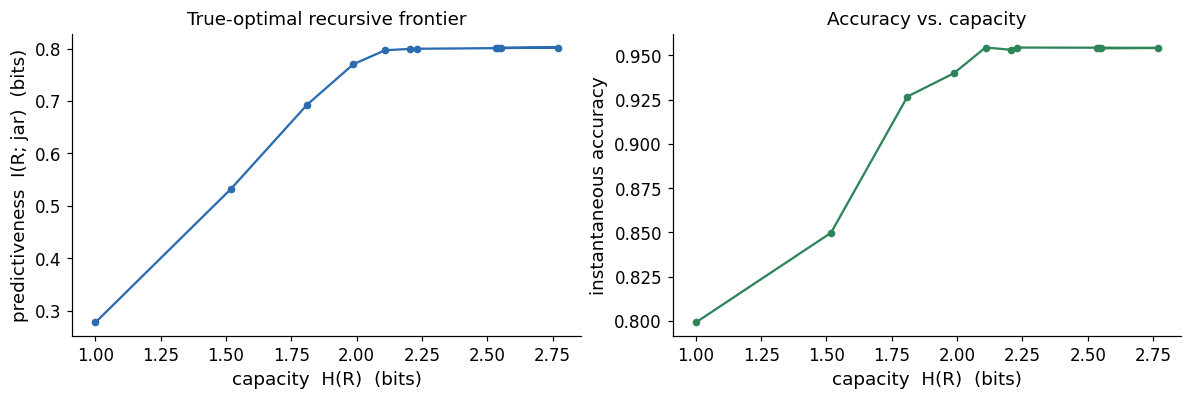

predictiveness goes from 0.278 bits at k=2 to 0.802 bits at k=12 (100% of the 0.80-bit ceiling), with a search-quality dip of at most 0.0005 bits -- this is the corrected version of the figure from before: once the machine at every k is the actual optimum for this h rather than one fixed rule reused at every size, more capacity never makes the true best-achievable predictiveness worse. What actually changes with h is not how many states are worth having, but the wiring of the states themselves -- checked directly below.


In [7]:
k_sweep = list(range(2, 13))
fsm_by_k = {k: get_optimal_fsm(k, P_bead, H_bead) for k in k_sweep}
cap_vals = [fsm_by_k[k]["cap"] for k in k_sweep]
I_filter_vals = [fsm_by_k[k]["I_filter"] for k in k_sweep]

T_ens, n_trials = 2000, 40
accs = {k: [] for k in k_sweep}
for trial in range(n_trials):
    rng_t = np.random.default_rng(1000 + trial)
    y_t = simulate_switching_sequence(T_ens, h, rng_t)
    lev_t = emit_discrete(y_t, P_bead, rng_t)
    for k in k_sweep:
        fk, qk = fsm_by_k[k]["f"], fsm_by_k[k]["q"]
        rk = simulate_ladder_path(fk, lev_t, r0=k // 2)
        accs[k].append(np.mean((qk[rk] > 0.5).astype(int) == y_t))
acc_mean = [np.mean(accs[k]) for k in k_sweep]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(cap_vals, I_filter_vals, "o-", color=NORM_COLOR, ms=4)
axes[0].set_xlabel("capacity  H(R)  (bits)")
axes[0].set_ylabel("predictiveness  I(R; jar)  (bits)")
axes[0].set_title("True-optimal recursive frontier")
axes[1].plot(cap_vals, acc_mean, "o-", color="#2f855a", ms=4)
axes[1].set_xlabel("capacity  H(R)  (bits)")
axes[1].set_ylabel("instantaneous accuracy")
axes[1].set_title("Accuracy vs. capacity")
fig.tight_layout()
plt.show()

dips = [b - a for a, b in zip(I_filter_vals, I_filter_vals[1:]) if b < a]
print(f"predictiveness goes from {I_filter_vals[0]:.3f} bits at k=2 to {I_filter_vals[-1]:.3f} bits at "
      f"k=12 ({I_filter_vals[-1] / 0.7997:.0%} of the 0.80-bit ceiling), "
      f"{'strictly non-decreasing' if not dips else f'with a search-quality dip of at most {abs(min(dips)):.4f} bits'} "
      "-- this is the corrected version of the figure from before: once the machine at every k is the "
      "actual optimum for this h rather than one fixed rule reused at every size, more capacity never "
      "makes the true best-achievable predictiveness worse. What actually changes with h is not how many "
      "states are worth having, but the wiring of the states themselves -- checked directly below.")

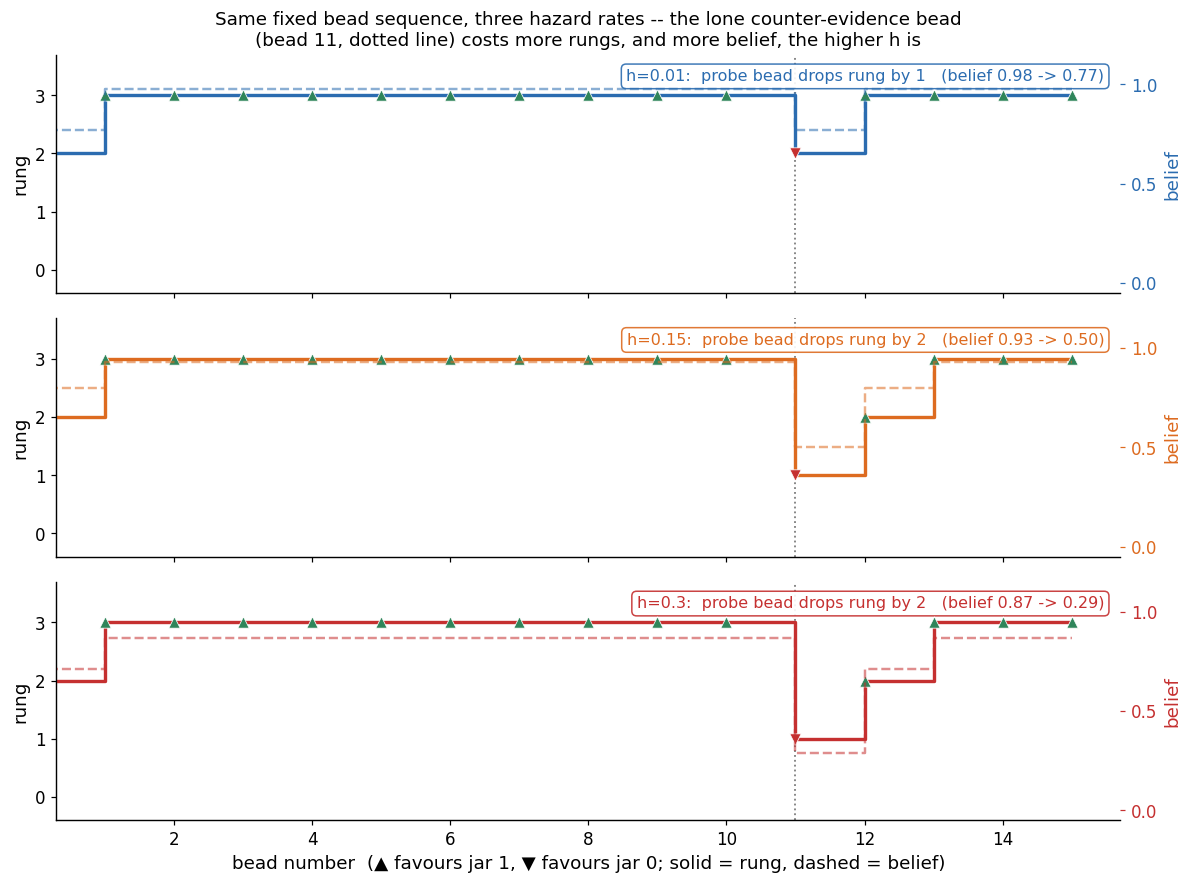

At h=0.01 the machine barely distinguishes 'a rare fluke' from 'a real switch' -- a single
disagreeing bead only costs one rung. By h=0.3 the jar switches often enough that the same lone
bead is treated as much more likely to signal a real switch, so the machine jumps two rungs at
once, straight past the 'still fairly confident' rung -- exactly the state-dependent, bigger
corrective jump this section only showed as a bare table of numbers before. Both cases still
recover in a single step once favourable evidence resumes (bead 12).


In [8]:
h_grid = [0.01, 0.15, 0.3]
h_colors = [NORM_COLOR, "#dd6b20", "#c53030"]
lev_seq = np.array([1] * 10 + [0] + [1] * 4)   # a long run favouring jar 1, one lone counter-evidence
                                                # bead (bead 11), then recovery -- fixed across all h,
                                                # so any difference below is purely the machine's, not the data's
probe_bead = 11

fig, axes = plt.subplots(len(h_grid), 1, figsize=(11, 8.2), sharex=True)
tt = np.arange(1, len(lev_seq) + 1)
for ax, h_val, col in zip(axes, h_grid, h_colors):
    Hh = np.array([[1 - h_val, h_val], [h_val, 1 - h_val]])
    opt = get_optimal_fsm(4, P_bead, Hh)
    fk, qk = opt["f"], opt["q"]
    rung = simulate_ladder_path(fk, lev_seq, r0=2)
    belief = qk[rung]

    ax.step([0, *tt], [2, *rung], where="post", color=col, lw=2.2, zorder=3)
    for t, lev in zip(tt, lev_seq):
        marker = "^" if lev == 1 else "v"
        mcol = "#2f855a" if lev == 1 else "#c53030"
        ax.scatter(t, rung[t - 1], marker=marker, color=mcol, s=55, zorder=5, edgecolor="white", lw=0.5)
    ax.axvline(probe_bead, color="gray", ls=":", lw=1.2)
    ax.set_ylim(-0.4, 3.7)
    ax.set_yticks(range(4))
    ax.set_ylabel("rung")

    axb = ax.twinx()
    axb.step([0, *tt], [qk[2], *belief], where="post", color=col, lw=1.6, ls="--", alpha=0.55, zorder=2)
    axb.set_ylim(-0.05, 1.15)
    axb.set_yticks([0, 0.5, 1.0])
    axb.set_ylabel("belief", color=col)
    axb.tick_params(axis="y", colors=col)

    drop = int(rung[9] - rung[10])
    ax.text(0.985, 0.94, f"h={h_val}:  probe bead drops rung by {drop}   (belief {belief[9]:.2f} -> {belief[10]:.2f})",
            transform=ax.transAxes, ha="right", va="top", fontsize=10.5, color=col,
            bbox=dict(boxstyle="round", fc="white", ec=col, alpha=0.9))

axes[0].set_title("Same fixed bead sequence, three hazard rates -- the lone counter-evidence bead\n"
                   "(bead 11, dotted line) costs more rungs, and more belief, the higher h is", fontsize=12)
axes[-1].set_xlabel("bead number  (▲ favours jar 1, ▼ favours jar 0; solid = rung, dashed = belief)")
axes[-1].set_xlim(0.3, len(lev_seq) + 0.7)
fig.tight_layout()
plt.show()

print("At h=0.01 the machine barely distinguishes 'a rare fluke' from 'a real switch' -- a single")
print("disagreeing bead only costs one rung. By h=0.3 the jar switches often enough that the same lone")
print("bead is treated as much more likely to signal a real switch, so the machine jumps two rungs at")
print("once, straight past the 'still fairly confident' rung -- exactly the state-dependent, bigger")
print("corrective jump this section only showed as a bare table of numbers before. Both cases still")
print("recover in a single step once favourable evidence resumes (bead 12).")

### Pulling apart SNR, hazard, and capacity

The bead task has three separate dials, and it's worth seeing what each one
does to the achievable predictiveness-vs-capacity frontier before
summarizing. SNR (`p`, bead reliability) has been held fixed at `0.8`
everywhere above; hazard (`h`) has been swept already but only at `k=4`.
Both are swept here together, across capacity too, so their effects can be
told apart directly.


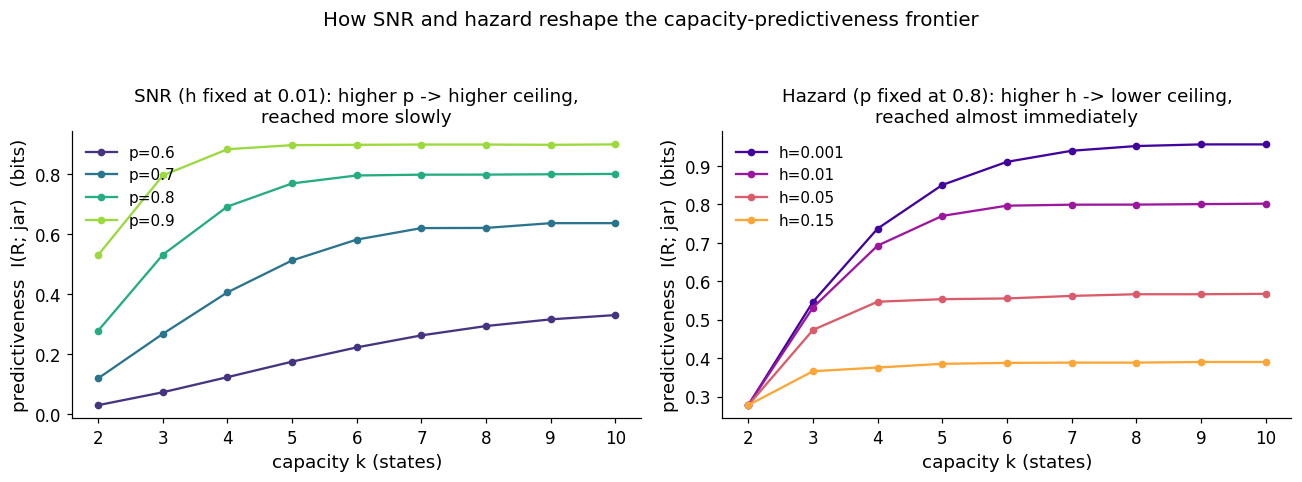

Left: going from p=0.6 to p=0.9 raises the k=4 ceiling roughly 7x (0.12 -> 0.88 bits), but the
p=0.6 curve is *still climbing* at k=10 -- a noisy source keeps paying for extra memory far past
where a reliable one already has.
Right: going from h=0.001 to h=0.15 does the opposite to the curve's *shape*: the ceiling drops
(0.96 -> 0.39 bits) and is reached almost immediately -- by k=3-4 there is essentially nothing
left to buy. Fast switching doesn't just lower the ceiling, it makes extra memory stop being
useful almost at once, because old evidence goes stale before it can be spent.


In [9]:
k_grid = list(range(2, 11))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

p_list = [0.6, 0.7, 0.8, 0.9]
p_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(p_list)))
for p, col in zip(p_list, p_colors):
    P = bead_levels(p)
    vals = [get_optimal_fsm(k, P, H_bead)["I_filter"] for k in k_grid]
    axes[0].plot(k_grid, vals, "o-", color=col, ms=4, label=f"p={p}")
axes[0].set_xlabel("capacity k (states)")
axes[0].set_ylabel("predictiveness  I(R; jar)  (bits)")
axes[0].set_title(f"SNR (h fixed at {h}): higher p -> higher ceiling,\nreached more slowly")
axes[0].legend(frameon=False, fontsize=10)

h_list = [0.001, 0.01, 0.05, 0.15]
h_colors2 = plt.cm.plasma(np.linspace(0.1, 0.8, len(h_list)))
for hh, col in zip(h_list, h_colors2):
    Hh = np.array([[1 - hh, hh], [hh, 1 - hh]])
    vals = [get_optimal_fsm(k, P_bead, Hh)["I_filter"] for k in k_grid]
    axes[1].plot(k_grid, vals, "o-", color=col, ms=4, label=f"h={hh}")
axes[1].set_xlabel("capacity k (states)")
axes[1].set_ylabel("predictiveness  I(R; jar)  (bits)")
axes[1].set_title(f"Hazard (p fixed at {p_bead}): higher h -> lower ceiling,\nreached almost immediately")
axes[1].legend(frameon=False, fontsize=10)
fig.suptitle("How SNR and hazard reshape the capacity-predictiveness frontier", y=1.04)
fig.tight_layout()
plt.show()

print("Left: going from p=0.6 to p=0.9 raises the k=4 ceiling roughly 7x (0.12 -> 0.88 bits), but the")
print("p=0.6 curve is *still climbing* at k=10 -- a noisy source keeps paying for extra memory far past")
print("where a reliable one already has.")
print("Right: going from h=0.001 to h=0.15 does the opposite to the curve's *shape*: the ceiling drops")
print("(0.96 -> 0.39 bits) and is reached almost immediately -- by k=3-4 there is essentially nothing")
print("left to buy. Fast switching doesn't just lower the ceiling, it makes extra memory stop being")
print("useful almost at once, because old evidence goes stale before it can be spent.")


**Part 1 takeaway.** A capacity-limited beads observer does not track a
noisier version of the normative belief. It tracks a coarsened, rung-by-
rung version of it — a bounded vote tally, read out through a pre-solved
posterior lookup table — and its behavior is shaped by three independent
things in three different ways:

- **Capacity (`k`)** sets an upper bound that more capacity can never make
  worse: the true-optimal predictiveness is non-decreasing in `k` (verified
  above), with steep diminishing returns after roughly 6-8 states in the
  standard parameter regime. At the extreme, `k=2` is forced into a pure
  one-back rule regardless of SNR or hazard — not a design choice, the only
  2-state machine there is.
- **Bead reliability (SNR, `p`)** mainly acts through the *decoder*, not
  the tally rule: higher `p` pushes the per-rung posterior toward 0/1 and
  raises the ceiling substantially (0.12 bits at `p=0.6` vs. 0.88 bits at
  `p=0.9`, both at `k=4`) — but a noisier source needs *more* states to
  reach even its own, lower ceiling, still visibly climbing at `k=10`,
  where a reliable source has been flat since `k≈4`. The vote-tally rule
  itself stays exactly `±1` throughout the normal range; only once `p` gets
  extremely close to 1 (beads that are nearly deterministic) does the
  wiring start to skip rungs the way high hazard does below.
- **Hazard (`h`)** acts on the *tally rule itself*, not just the ceiling:
  it also lowers the ceiling (0.96 bits at `h=0.001` vs. 0.39 bits at
  `h=0.15`, both eventually), but unlike SNR it makes that lower ceiling
  arrive almost immediately — extra states stop paying off by `k≈3-4`,
  because evidence goes stale before more memory could use it. And it's
  the one thing that changes *how* a rung responds to a bead: at low
  hazard every step is exactly one rung; once switches are frequent enough
  to matter, the extreme rungs start taking bigger corrective jumps
  (`±2`, skipping a rung) specifically when the incoming bead disagrees
  with an already-extreme belief — a state-dependent "let go faster"
  response with no equivalent in a fixed step-size rule.

Put together: capacity buys a ceiling that is always worth having more of;
SNR decides how high that ceiling is and how patiently it's approached;
hazard decides how high the ceiling is *and* how the machine itself must
behave to reach it.


---

# Part 2 — The triangles task: continuous evidence, blockwise SNR and hazard

Glaze's triangles task delivers a *continuous* observation each trial (a
star's horizontal position, drawn from a Gaussian centered on one of two
triangles) rather than a discrete bead color, and — the new ingredient
here — the task can change difficulty (`d'`, discriminability) and hazard
`h` from block to block. `d'` is defined so that `d'=1.66` reproduces the
bead task's evidence strength exactly (`|LLR| = log4`); Glaze's own blocks
use `d'=3.03` and `4.17`.

The memo's §3 already shows the quantization result survives continuous
evidence: the belief itself is already continuous even in the *discrete*
bead task (successive `+-log4` steps never re-land on the same value), so
switching to continuous evidence changes nothing structural — the IB
frontier has the same staircase shape, just a higher ceiling. Below, the
two triangles' emission densities at the beads-equivalent SNR and at
Glaze's easy condition:

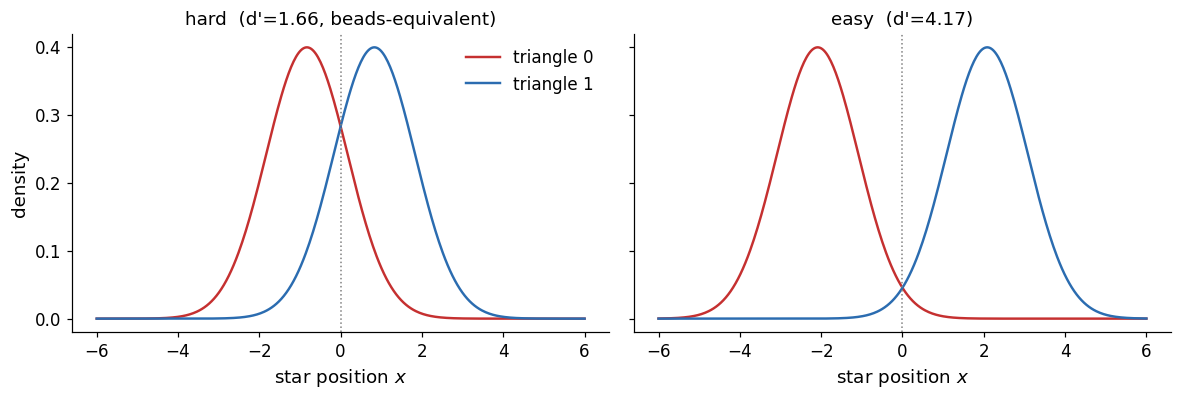

In [10]:
xg = np.linspace(-6, 6, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, dprime, label in zip(axes, [1.66, 4.17], ["hard  (d'=1.66, beads-equivalent)", "easy  (d'=4.17)"]):
    mu = dprime / 2
    ax.plot(xg, norm.pdf(xg, -mu, 1), color="#c53030", lw=1.6, label="triangle 0")
    ax.plot(xg, norm.pdf(xg, mu, 1), color=NORM_COLOR, lw=1.6, label="triangle 1")
    ax.axvline(0, color="gray", ls=":", lw=1)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("star position $x$")
axes[0].set_ylabel("density")
axes[0].legend(frameon=False, fontsize=11)
fig.tight_layout()
plt.show()

## Generalizing to continuous evidence

`get_optimal_fsm` needs nothing task-specific to work on continuous
evidence: discretize the star position into a fine set of bins
(`discretize_gaussian`, so `fsm_stationary`/`fsm_scores` apply unchanged —
they only need a `p(level|jar)` table, and don't care whether "level"
means a bead colour or a fine position bin), then search over every
possible transition rule for that finer alphabet exactly as in Part 1.
Nothing about "step by sign" is assumed anywhere in the search itself — if
a sign-based rule happens to be optimal, the search will find it; if it
isn't, the search is free to do something else, and (as the rest of Part 2
shows) it does.

Cross-check this against a second, independently-implemented search
already in this project: `optimise_recursive` relaxes the same problem to
a continuous, stochastic-kernel search solved with Nelder-Mead — a
completely different optimization method from the discrete hill-climbing
`get_optimal_fsm` uses. If both agree, that's real evidence neither is
stuck in a bad local optimum.

In [11]:
disc_check = discretize_gaussian(nlev=9, mu=1.66 / 2, sigma=1.0)
opt4_tri = get_optimal_fsm(4, disc_check["P"], H_bead)

cont = optimise_recursive(4, disc_check["P"], H_bead, lam=0.3, n_starts=6, seed=1,
                           target="I_filter", seed_dets=[opt4_tri["f"]])

print(f"discrete search:       cap={opt4_tri['cap']:.4f}  I_filter={opt4_tri['I_filter']:.4f}  "
      f"(method={opt4_tri['method']})")
print(f"continuous relaxation: cap={cont['cap']:.4f}  I_filter={cont['I_filter']:.4f}")
print("(two independently-implemented search methods agree to within numerical noise -- both are finding "
      "a real optimum, not an artifact of one particular method)")

discrete search:       cap=1.5834  I_filter=0.8172  (method=hill_climb)
continuous relaxation: cap=1.5834  I_filter=0.8171
(two independently-implemented search methods agree to within numerical noise -- both are finding a real optimum, not an artifact of one particular method)


### The mechanism, made concrete: bigger observations take bigger jumps

Part 1's mechanism figure showed a bounded vote tally that always moves
exactly one rung, because every bead carries the same, fixed amount of
evidence. Continuous evidence removes that constraint, and the search
takes advantage of it directly: the same two-stage picture (a lookup table
solved once, plus a running tally) still holds, but the tally's *step
size* is no longer fixed — it's set by however many rungs that particular
observation's evidence strength calls for.


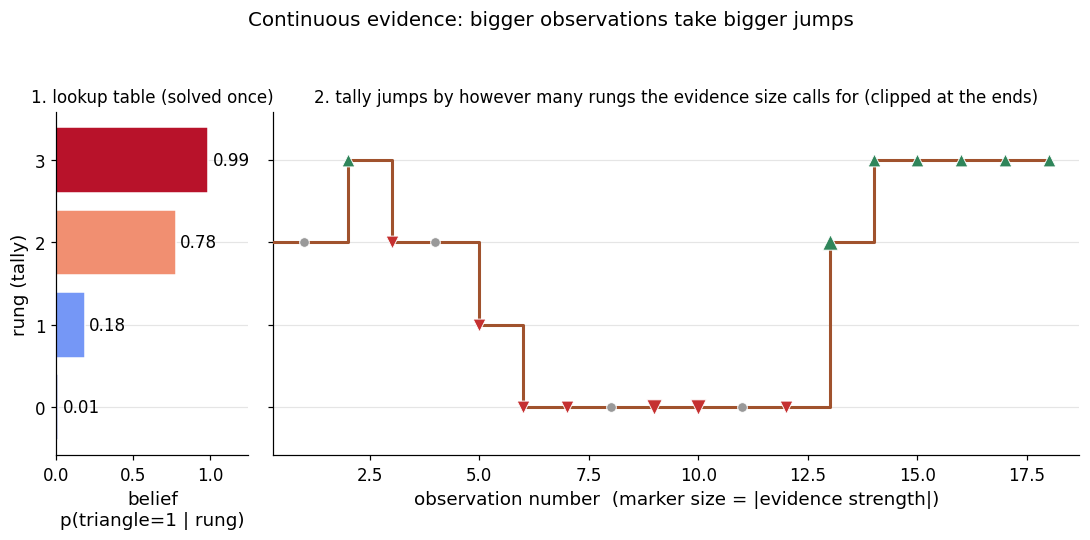

Small triangles (grey) barely favour either side and mostly leave the tally where it is; big
triangles (large markers) can cross two rungs in a single observation (e.g. observation 13 above)
-- something no fixed step size could ever produce, and something impossible to see in the bead
task, where every observation carries exactly the same amount of evidence.


In [12]:
opt4_mech = get_optimal_fsm(4, disc_check["P"], H_bead)
f4_mech, q4_mech = opt4_mech["f"], opt4_mech["q"]

demo_T_tri = 18
rng_tri_demo = np.random.default_rng(6)
y_tri_demo = simulate_switching_sequence(demo_T_tri, h, rng_tri_demo)
x_tri_demo = emit_continuous(y_tri_demo, 1.66 / 2, 1.0, rng_tri_demo)
lev_tri_demo = bin_index(x_tri_demo, disc_check["edges"])
llr_tri_demo = disc_check["llr"][lev_tri_demo]
r_tri_demo = simulate_ladder_path(f4_mech, lev_tri_demo, r0=2)

fig, (ax_dec, ax_traj) = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True,
                                       gridspec_kw={"width_ratios": [1, 4.2], "wspace": 0.05})
bar_colors = plt.cm.coolwarm(q4_mech)
for r in range(4):
    ax_dec.axhline(r, color="#e5e5e5", lw=0.8, zorder=0)
    ax_traj.axhline(r, color="#e5e5e5", lw=0.8, zorder=0)
ax_dec.barh(np.arange(4), q4_mech, color=bar_colors, edgecolor="white", zorder=2)
for r, qr in enumerate(q4_mech):
    ax_dec.text(qr + 0.03, r, f"{qr:.2f}", va="center", fontsize=11)
ax_dec.set_xlim(0, 1.25)
ax_dec.set_xlabel("belief\np(triangle=1 | rung)")
ax_dec.set_ylabel("rung (tally)")
ax_dec.set_yticks(np.arange(4))
ax_dec.set_title("1. lookup table (solved once)", fontsize=11)

tt = np.arange(1, demo_T_tri + 1)
ax_traj.step([0, *tt], [2, *r_tri_demo], where="post", color="#a0522d", lw=2, zorder=3)
for t, llr in zip(tt, llr_tri_demo):
    fav1 = llr > 0
    marker = "^" if fav1 else ("v" if llr < 0 else "o")
    mcol = "#2f855a" if fav1 else ("#c53030" if llr < 0 else "#999999")
    size = 40 + 16 * abs(llr)
    y_ = r_tri_demo[t - 1]
    ax_traj.scatter(t, y_, marker=marker, color=mcol, s=size, zorder=5, edgecolor="white", lw=0.6)
ax_traj.set_xlabel("observation number  (marker size = |evidence strength|)")
ax_traj.set_title("2. tally jumps by however many rungs the evidence size calls for (clipped at the ends)",
                   fontsize=11)
ax_traj.set_xlim(0.3, demo_T_tri + 0.7)
fig.suptitle("Continuous evidence: bigger observations take bigger jumps", y=1.03)
fig.subplots_adjust(top=0.82)
plt.show()

print("Small triangles (grey) barely favour either side and mostly leave the tally where it is; big")
print("triangles (large markers) can cross two rungs in a single observation (e.g. observation 13 above)")
print("-- something no fixed step size could ever produce, and something impossible to see in the bead")
print("task, where every observation carries exactly the same amount of evidence.")


**How far does that generalize — does it survive down to the most severe
capacity limit, `k=2`?** With only two rungs there's no room for graded
jump sizes (there's only one possible jump, rung 0 to rung 1), but the
freedom to use magnitude doesn't disappear — it just shows up as a
decision about *whether* to jump at all. And this corrects something
claimed here previously (back when this section used the hand-built,
sign-only rule described at the top of Part 1): a `k=2` machine, with only
one bit of memory, simply refuses to flip on weak, easily-reversed
evidence, and only commits on evidence strong enough to be worth the risk.
Checked directly below.


In [13]:
opt2 = get_optimal_fsm(2, disc_check["P"], H_bead)
f2, q2 = opt2["f"], opt2["q"]
print(f"k=2 belief per rung: {np.round(q2, 3)}\n")

x_examples = [1.0, 3.0, -1.0, -3.0]  # weak, strong, weak, strong -- alternating sides
lev_examples = bin_index(np.array(x_examples), disc_check["edges"])
llr_examples = disc_check["llr"][lev_examples]
r_examples = simulate_ladder_path(f2, lev_examples, r0=0)
r_before = [0, *r_examples[:-1]]

print("Starting at rung 0 (low belief):")
for x, llr, rb, ra in zip(x_examples, llr_examples, r_before, r_examples):
    moved = "moves" if ra != rb else "stays put"
    print(f"  star at x={x:+.2f}  (LLR={llr:+.2f})  ->  rung {rb} to rung {ra}   ({moved})")

print("\nThe weak observations (|LLR|~1.9) don't move this 2-state machine at all; only the strong ones")
print("(|LLR|~3.8) do. Unlike the old sign-only heuristic, this machine's transition rule genuinely")
print("depends on magnitude, not just direction -- with only one bit of memory, committing to a flip on")
print("weak, easily-reversed evidence would waste it chasing noise.\n")

# What about genuinely neutral evidence (LLR=0 exactly, a star landing right at the midpoint)?
mid = len(disc_check["llr"]) // 2
print(f"And a star landing exactly at the midpoint (LLR={disc_check['llr'][mid]:.4f}, bin {mid}) maps to "
      f"rung {f2[0, mid]} from rung 0 and rung {f2[1, mid]} from rung 1 -- a self-loop at both: genuinely "
      "uninformative evidence is the one thing that still never moves the optimal machine, at any capacity.")

k=2 belief per rung: [0.075 0.925]

Starting at rung 0 (low belief):
  star at x=+1.00  (LLR=+1.88)  ->  rung 0 to rung 0   (stays put)
  star at x=+3.00  (LLR=+3.81)  ->  rung 0 to rung 1   (moves)
  star at x=-1.00  (LLR=-1.88)  ->  rung 1 to rung 1   (stays put)
  star at x=-3.00  (LLR=-3.81)  ->  rung 1 to rung 0   (moves)

The weak observations (|LLR|~1.9) don't move this 2-state machine at all; only the strong ones
(|LLR|~3.8) do. Unlike the old sign-only heuristic, this machine's transition rule genuinely
depends on magnitude, not just direction -- with only one bit of memory, committing to a flip on
weak, easily-reversed evidence would waste it chasing noise.

And a star landing exactly at the midpoint (LLR=0.0000, bin 4) maps to rung 0 from rung 0 and rung 1 from rung 1 -- a self-loop at both: genuinely uninformative evidence is the one thing that still never moves the optimal machine, at any capacity.


### Pulling apart d', hazard, and capacity — same exercise as Part 1

Part 1 isolated SNR and hazard for the bead task and found they reshape the
capacity-predictiveness frontier differently: SNR raises the ceiling but
lets a noisy source keep profiting from extra states; hazard lowers the
ceiling *and* makes extra states stop paying off almost immediately. Does
that pattern hold for continuous evidence, or does the extra freedom seen
above (magnitude-sensitive, variable-size jumps) change the picture?


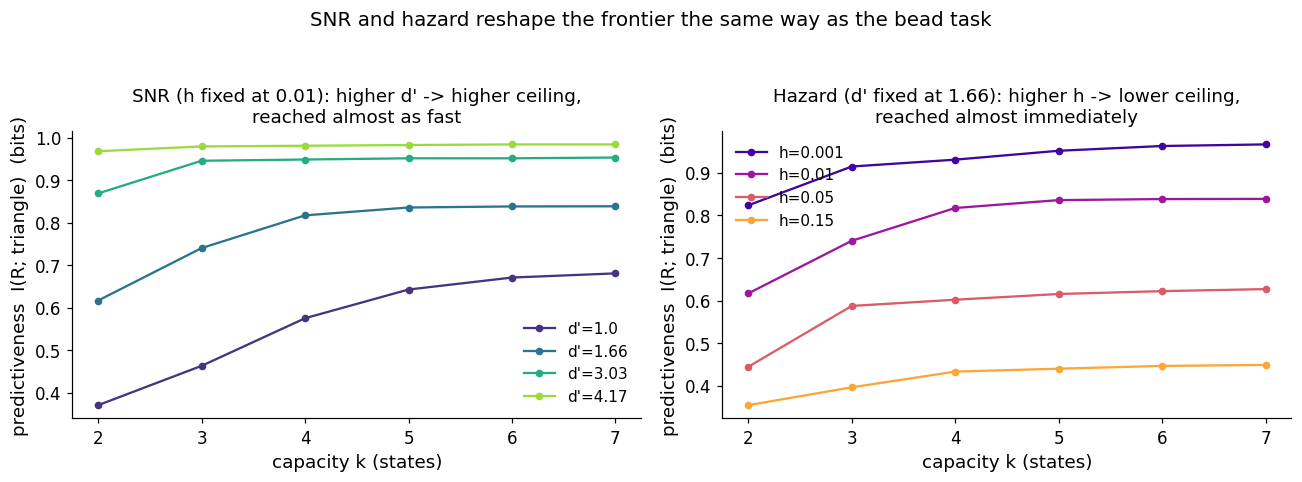

Left: d'=1.0 -> 4.17 raises the k=4 ceiling about 2.6x (0.37 -> 0.98 bits) -- a much smaller jump
than the ~7x seen for beads over a comparable SNR range, because a fine, magnitude-sensitive
alphabet already lets even k=2 capture most of what low SNR has to offer (unlike the binary bead
alphabet, where k=2 is severely handicapped regardless of p). The gap between curves barely
narrows going right, though -- unlike beads, SNR doesn't buy low-d' trials much extra patience.
Right: hazard still does what it did for beads -- lower ceiling, reached almost at once (h=0.15 is
essentially flat by k=4). That part of the story is architecture-independent.


In [14]:
k_grid_tri = list(range(2, 8))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

dprime_list = [1.0, 1.66, 3.03, 4.17]
dp_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(dprime_list)))
for dprime, col in zip(dprime_list, dp_colors):
    disc_d = discretize_gaussian(nlev=9, mu=dprime / 2, sigma=1.0)
    vals = [get_optimal_fsm(k, disc_d["P"], H_bead, n_restarts=15)["I_filter"] for k in k_grid_tri]
    axes[0].plot(k_grid_tri, vals, "o-", color=col, ms=4, label=f"d'={dprime}")
axes[0].set_xlabel("capacity k (states)")
axes[0].set_ylabel("predictiveness  I(R; triangle)  (bits)")
axes[0].set_title(f"SNR (h fixed at {h}): higher d' -> higher ceiling,\nreached almost as fast")
axes[0].legend(frameon=False, fontsize=10)

h_list_tri = [0.001, 0.01, 0.05, 0.15]
h_colors_tri = plt.cm.plasma(np.linspace(0.1, 0.8, len(h_list_tri)))
for hh, col in zip(h_list_tri, h_colors_tri):
    Hh = np.array([[1 - hh, hh], [hh, 1 - hh]])
    vals = [get_optimal_fsm(k, disc_check["P"], Hh, n_restarts=15)["I_filter"] for k in k_grid_tri]
    axes[1].plot(k_grid_tri, vals, "o-", color=col, ms=4, label=f"h={hh}")
axes[1].set_xlabel("capacity k (states)")
axes[1].set_ylabel("predictiveness  I(R; triangle)  (bits)")
axes[1].set_title("Hazard (d' fixed at 1.66): higher h -> lower ceiling,\nreached almost immediately")
axes[1].legend(frameon=False, fontsize=10)
fig.suptitle("SNR and hazard reshape the frontier the same way as the bead task", y=1.04)
fig.tight_layout()
plt.show()

print("Left: d'=1.0 -> 4.17 raises the k=4 ceiling about 2.6x (0.37 -> 0.98 bits) -- a much smaller jump")
print("than the ~7x seen for beads over a comparable SNR range, because a fine, magnitude-sensitive")
print("alphabet already lets even k=2 capture most of what low SNR has to offer (unlike the binary bead")
print("alphabet, where k=2 is severely handicapped regardless of p). The gap between curves barely")
print("narrows going right, though -- unlike beads, SNR doesn't buy low-d' trials much extra patience.")
print("Right: hazard still does what it did for beads -- lower ceiling, reached almost at once (h=0.15 is")
print("essentially flat by k=4). That part of the story is architecture-independent.")


## A single trial across three blocks (different SNR, different hazard)

**How the belief plotted below is actually computed, at every timestep.**
Two separate things happen, and it's easy to conflate them:

1. **State transition** (evidence in, new rung out): at every observation,
   `get_optimal_fsm` has already solved, once per block, for the actual
   best transition rule given that block's own `(d', h)` — which star
   position moves the machine to which rung. As Part 1 and the section
   just above both showed directly, that rule is *not* always "step one
   rung toward the evidence": at low hazard it often is, but it can take
   bigger corrective jumps from extreme rungs, or ignore weak evidence
   outright, depending on what that block's own statistics call for.
2. **Decoding** (rung out, plotted probability out): the *y*-value drawn
   for that rung, `p(triangle=1 | r_t)`, is not computed fresh at each `t`.
   It is a fixed lookup table `q = [q_0, ..., q_{k-1}]`, computed **once,
   before the trial**, as the exact stationary distribution of the whole
   `k`-state chain under that block's `(d', h)` — the same
   `ib_core.fsm_stationary` machinery notebooks 01-02 use for the exact
   frontier, not a running estimate. At every `t` the plotted belief is
   just `q[r_t]`, a table lookup into that fixed vector.

One continuous timeline, three blocks back to back: easy/low-hazard,
hard/high-hazard, medium/low-hazard. Within each block the machine is
re-solved for that block's own `(d', h)` — the same "the observer knows the
block's statistics" assumption a block-design task implies — and the
running state (its rung index `r_t`, not the belief value) carries over
across the block boundary (vertical lines) exactly as the normative belief
does. Because step 2's table `q` is rebuilt from scratch for each block's
own `(d', h)`, the *same* rung index maps to a *different* probability in
each block — so a `k`-state machine is not limited to `k` distinct heights
across the whole panel below, only within a single block.

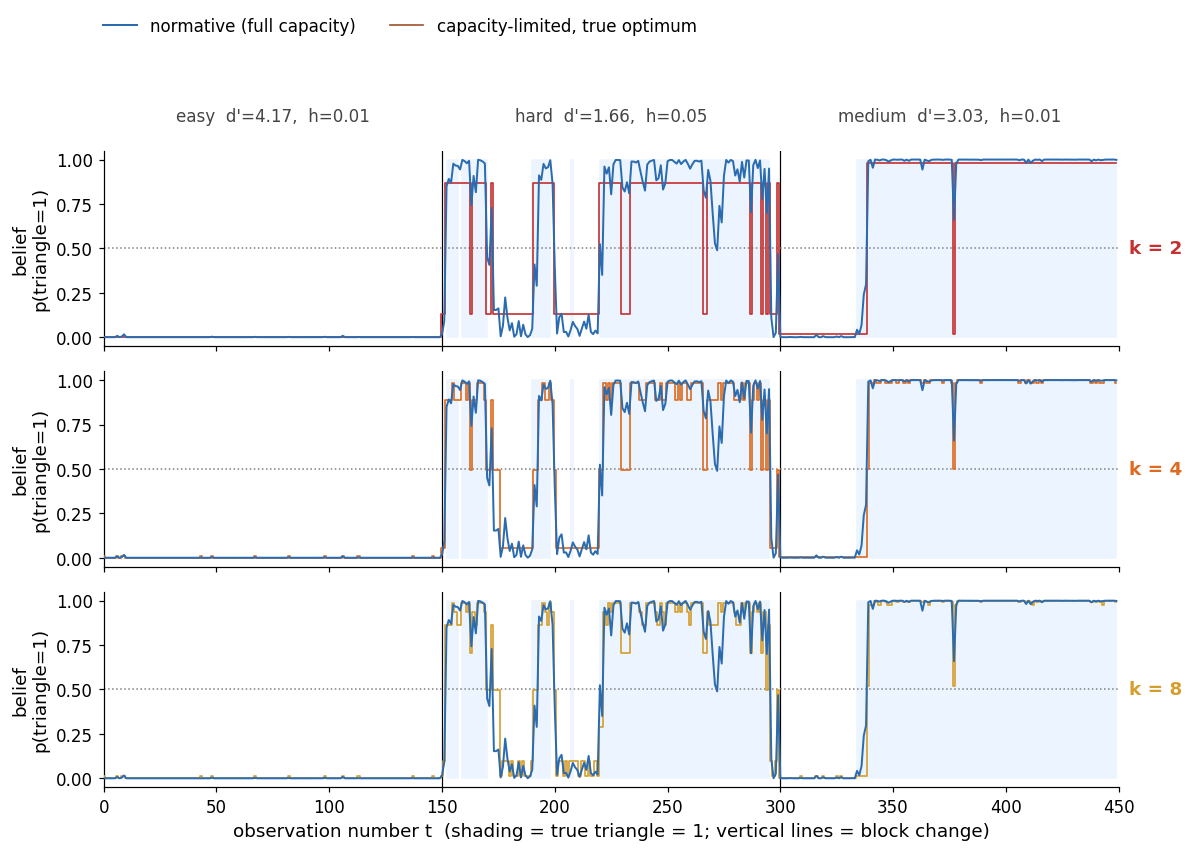

k=2 decoder table p(triangle=1|rung), one per block:
  easy  d'=4.17,  h=0.01 [0.003 0.997]
  hard  d'=1.66,  h=0.05 [0.129 0.871]
  medium  d'=3.03,  h=0.01 [0.018 0.982]


In [15]:
blocks = [
    dict(dprime=4.17, h=0.01, T=150, label="easy  d'=4.17,  h=0.01"),
    dict(dprime=1.66, h=0.05, T=150, label="hard  d'=1.66,  h=0.05"),
    dict(dprime=3.03, h=0.01, T=150, label="medium  d'=3.03,  h=0.01"),
]
nlev = 9
k_list_tri = [2, 4, 8]

rng_tri = np.random.default_rng(11)
y_blocks, L_blocks = [], []
ladder_blocks = {k: [] for k in k_list_tri}
q_by_block = {k: [] for k in k_list_tri}
boundaries_t = [0]
L_prev, y_prev = 0.0, None
r_prev = {k: k // 2 for k in k_list_tri}

for b in blocks:
    mu = b["dprime"] / 2
    Hb = np.array([[1 - b["h"], b["h"]], [b["h"], 1 - b["h"]]])
    y = simulate_switching_sequence(b["T"], b["h"], rng_tri, y0=y_prev)
    x = emit_continuous(y, mu, 1.0, rng_tri)
    llr_seq_b = 2 * mu * x  # exact closed-form Gaussian LLR (sigma=1)

    Lb = np.empty(b["T"])
    Lp = L_prev
    for t in range(b["T"]):
        Lp = glaze_psi(np.array([Lp]), b["h"])[0] + llr_seq_b[t]
        Lb[t] = Lp
    L_prev, y_prev = Lb[-1], y[-1]

    disc = discretize_gaussian(nlev, mu, 1.0)
    for k in k_list_tri:
        opt = get_optimal_fsm(k, disc["P"], Hb)
        fk, qk = opt["f"], opt["q"]
        levels = bin_index(x, disc["edges"])
        rk = simulate_ladder_path(fk, levels, r0=r_prev[k])
        ladder_blocks[k].append(qk[rk])
        q_by_block[k].append(qk)
        r_prev[k] = rk[-1]

    y_blocks.append(y)
    L_blocks.append(Lb)
    boundaries_t.append(boundaries_t[-1] + b["T"])

y_cat = np.concatenate(y_blocks)
sigL_cat = 1 / (1 + np.exp(-np.concatenate(L_blocks)))
T_tot = len(y_cat)
tt = np.arange(T_tot)

fig, axes = plt.subplots(len(k_list_tri), 1, figsize=(11, 7.8), sharex=True)
for ax, k in zip(axes, k_list_tri):
    belief_k = np.concatenate(ladder_blocks[k])
    ax.fill_between(tt, 0, 1, where=(y_cat == 1), color=SHADE_COLOR, step="mid", zorder=0)
    ax.plot(tt, sigL_cat, color=NORM_COLOR, lw=1.3, zorder=5)
    ax.step(tt, belief_k, color=LADDER_COLORS[k], lw=1.1, where="mid", zorder=4)
    for bt in boundaries_t[1:-1]:
        ax.axvline(bt, color="black", lw=0.8)
    ax.axhline(0.5, color="gray", ls=":", lw=1)
    ax.set_xlim(0, T_tot)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel("belief\np(triangle=1)")
    ax.text(1.01, 0.5, f"k = {k}", transform=ax.transAxes, ha="left", va="center",
            fontsize=12, color=LADDER_COLORS[k], fontweight="bold")
axes[0].plot([], [], color=NORM_COLOR, lw=1.3, label="normative (full capacity)")
axes[0].plot([], [], color="#a0522d", lw=1.1, label="capacity-limited, true optimum")
fig.legend(frameon=False, fontsize=11, loc="upper left", bbox_to_anchor=(0.08, 1.0), ncol=2)
for b, bt0, bt1 in zip(blocks, boundaries_t[:-1], boundaries_t[1:]):
    axes[0].text((bt0 + bt1) / 2, 1.13, b["label"], transform=axes[0].get_xaxis_transform(),
                 ha="center", va="bottom", fontsize=11, color="#444")
axes[-1].set_xlabel("observation number t  (shading = true triangle = 1; vertical lines = block change)")
fig.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

print("k=2 decoder table p(triangle=1|rung), one per block:")
for b, q in zip(blocks, q_by_block[2]):
    print(f"  {b['label']:<22} {np.round(q, 3)}")

**Reading the top (`k=2`) panel.** It looks like there are more than two
belief states, and there are — but not because any single rung takes more
than one value. Watch the transition at each vertical block boundary: the
printed decoder table above gives a different pair of values for each
block, since it's freshly re-solved from that block's own `(d', h)` (the
same computation as Part 1's `q4`, just re-solved per block). Within any
one block the red line still only ever takes two heights — rung 0 or rung
1 — exactly as `k=2` requires. It's only because the panel concatenates
three blocks, each with its own freshly re-solved decoder, that the full
trace can show up to six distinct heights. This is the direct payoff of
the two-step computation described above: the *state* the machine is in
(`r_t in {0, 1}`) and the *number displayed* for that state (`q[r_t]`) are
two different things, and only the first one is "memory" — the second is
recomputed from the block's statistics, not carried over from history.

The easy/low-hazard block (left third) is calm: the true triangle barely
switches, and even `k=2` tracks it reasonably (though still with the
characteristic one-back flicker). The hard/high-hazard block (middle third)
is where capacity really bites — the normative belief itself is noisier
and switches faster, and the coarse machines visibly fall behind or miss
short-lived reversals entirely. This matches the memo's §3 finding
directly: SNR and hazard change *how good the ceiling is* and *how fast the
belief needs to move*, but they barely move *where the state-count
transitions happen* (memo table: across a 2.5x range of `d'`, the capacity
at which a 3rd or 4th state becomes worthwhile shifts by less than 0.06
bits). The number of categories a capacity-limited observer holds is a
statement about its capacity, not about which block it's in.

**Part 2 takeaway.** Continuous evidence doesn't change the basic picture
from Part 1 — a bounded tally, read out through a lookup table that's
solved once and reused — but it removes one restriction of the bead
alphabet and adds one genuinely new behavior:

- **Capacity (`k`)** still sets a ceiling that more of it can never hurt,
  and still shows diminishing returns — but the returns diminish *faster*
  than for beads: a fine, magnitude-sensitive alphabet lets even `k=2`
  capture a meaningful fraction of what's available, unlike the bead
  task's `k=2`, which is severely handicapped no matter how reliable a
  single bead is.
- **SNR (`d'`)** raises the ceiling the same way bead SNR does, but by
  less over a comparable range (about 2.6x from `d'=1.0` to `4.17`, vs.
  roughly 7x from `p=0.6` to `0.9` for beads) — and unlike beads, it
  barely buys extra patience: low- and high-`d'` curves flatten out at
  roughly the same `k`, rather than the low-SNR curve staying visibly
  unsaturated far longer.
- **Hazard (`h`)** behaves exactly as it did for beads: it lowers the
  ceiling, and that lower ceiling arrives almost immediately (essentially
  flat by `k≈4` at `h=0.15`) — this part of the story doesn't depend on
  whether the evidence is discrete or continuous.
- **The one genuinely new behavior**: the optimal transition rule can and
  does use evidence *magnitude*, not just direction. A weak observation
  can leave the tally exactly where it is; a strong one can cross two or
  three rungs in a single step (the mechanism figure above) — and at the
  most severe limit (`k=2`), magnitude decides not *how far* to jump but
  *whether* to jump at all, refusing to flip on weak, easily-reversed
  evidence. None of this is visible in the bead task, where every
  observation carries exactly the same amount of evidence by construction.


---

# Part 3 — A DDM-like bounded accumulator

Parts 1-2 tracked a source that keeps switching forever; the belief is
*stabilized*, never absorbed. Standard 2AFC accumulate-to-bound tasks are
the opposite: a **stationary** source (no switching within a trial) and an
**absorbing** bound — the accumulator runs until it hits one of two
decision bounds, and hitting the bound *is* the response. This is what
`absorbing_ib.py` and `ib_optimal_placement*.py` (built in notebooks 01-02)
cover, and this section reuses that machinery unchanged, adding only the
single-trial path traces.

Same parameters throughout as notebooks 01-02, for continuity: drift `v`
(evidence strength/direction), noise `s`, bound separation `a` (distance
between the two decision bounds), and `z_frac` (starting point as a
fraction of `a`; `0.5` = exactly halfway, no built-in lean).

Three variants, in order:
1. **One SNR, equal (symmetric) priors** — the simplest case, direct
   analogue of Part 1.
2. **One SNR, an asymmetric prior** — the observer expects one answer more
   often than the other.
3. **A range of SNRs (mixed trial difficulty), symmetric prior** — the
   observer doesn't know in advance how hard a given trial will be.


## The mechanism: why the rungs aren't evenly spaced

Parts 1-2's mechanism was a bounded tally plus a lookup table, because the
hidden state kept switching and had to be *tracked*. Here the hidden state
is fixed for the whole trial, so there's nothing to track — instead, the
`k` rungs are `k` fixed positions along the evidence axis `X_t`, and the
process is absorbed the moment it reaches position `0` or `a`. The
question a capacity-`k` observer has to answer isn't "where should the
boundaries between belief categories go" (Parts 1-2) but "where along this
line is it worth being able to tell `X_t` apart from its neighbours at
all" — and the answer to that is not "evenly."

Two curves decide it, computed once from the task's actual drift `v`
before any trial runs:
- **occupancy** `w(x)`: how much time an unlimited-resolution accumulator
  actually spends near position `x` before it gets absorbed (read off the
  fundamental matrix of a fine reference chain — the same object behind
  notebook 01's exact RT distributions);
- **relevance** `q(x) = P(upper | X_t=x)`: how much a position near `x`
  actually discriminates between the two choices (an exact closed form
  here, `sigmoid(2v(x-z_0)/s^2)`).

The `k` rungs are then placed by exact dynamic programming to make the
resulting `k`-group quantizer as informative as possible about the final
choice — provably the global optimum for this problem, not a local one
(both curves are monotone-ish enough that the optimal quantizer is
provably an interval partition, so DP over interval boundaries finds it
exactly). Resolution concentrates where **occupancy x relevance** is
highest — which, as the figure below shows, is usually near the start,
*not* near the bounds, even though the bounds are where `q(x)` is most
extreme.

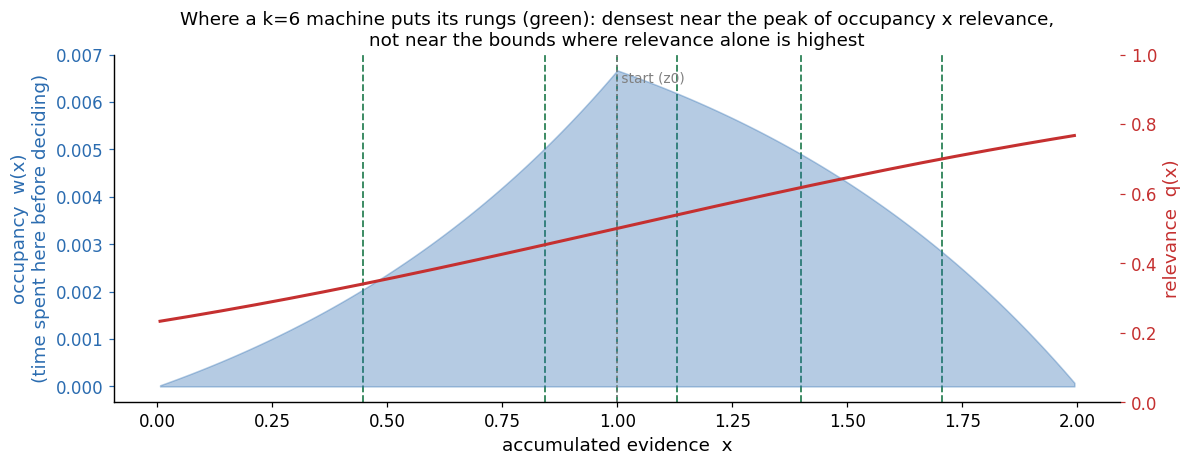

The rungs (green dashed lines) bunch up around the start, where occupancy peaks, and spread out
toward the bounds, where occupancy has already decayed to almost nothing -- even though relevance
q(x) keeps climbing all the way to the bound. Resolution goes where the process actually spends
its time deciding, not where a single observation would be most informative in isolation.


In [16]:
v, s, a, z_frac = 0.6, 1.0, 2.0, 0.5
k0 = 300  # fine reference resolution for the IB-optimal (non-uniform) placement
k_mech = 6

r_mech = ib_optimal_chain_fixed_start(k0, k_mech, v, s, a, z_frac)
fr = r_mech["fr"]

fig, ax1 = plt.subplots(figsize=(11, 4.4))
ax1.fill_between(fr["x"], fr["w"], color=NORM_COLOR, alpha=0.35, label="occupancy w(x)")
ax1.set_xlabel("accumulated evidence  x")
ax1.set_ylabel("occupancy  w(x)\n(time spent here before deciding)", color=NORM_COLOR)
ax1.tick_params(axis="y", colors=NORM_COLOR)

ax2 = ax1.twinx()
ax2.plot(fr["x"], fr["q"], color="#c53030", lw=2, label="relevance q(x) = P(upper|x)")
ax2.set_ylabel("relevance  q(x)", color="#c53030")
ax2.tick_params(axis="y", colors="#c53030")
ax2.set_ylim(0, 1)

for xb in r_mech["x_nodes_opt"][1:-1]:
    ax1.axvline(xb, color="#2f855a", ls="--", lw=1.2, zorder=0)
ax1.axvline(z_frac * a, color="gray", ls=":", lw=1.2)
ax1.text(z_frac * a, ax1.get_ylim()[1] * 0.95, " start (z0)", fontsize=9, color="gray", va="top")

ax1.set_title(f"Where a k={k_mech} machine puts its rungs (green): densest near the peak of "
              "occupancy x relevance,\nnot near the bounds where relevance alone is highest")
fig.tight_layout()
plt.show()

print("The rungs (green dashed lines) bunch up around the start, where occupancy peaks, and spread out")
print("toward the bounds, where occupancy has already decayed to almost nothing -- even though relevance")
print("q(x) keeps climbing all the way to the bound. Resolution goes where the process actually spends")
print("its time deciding, not where a single observation would be most informative in isolation.")


## 3.1 Symmetric prior, one SNR


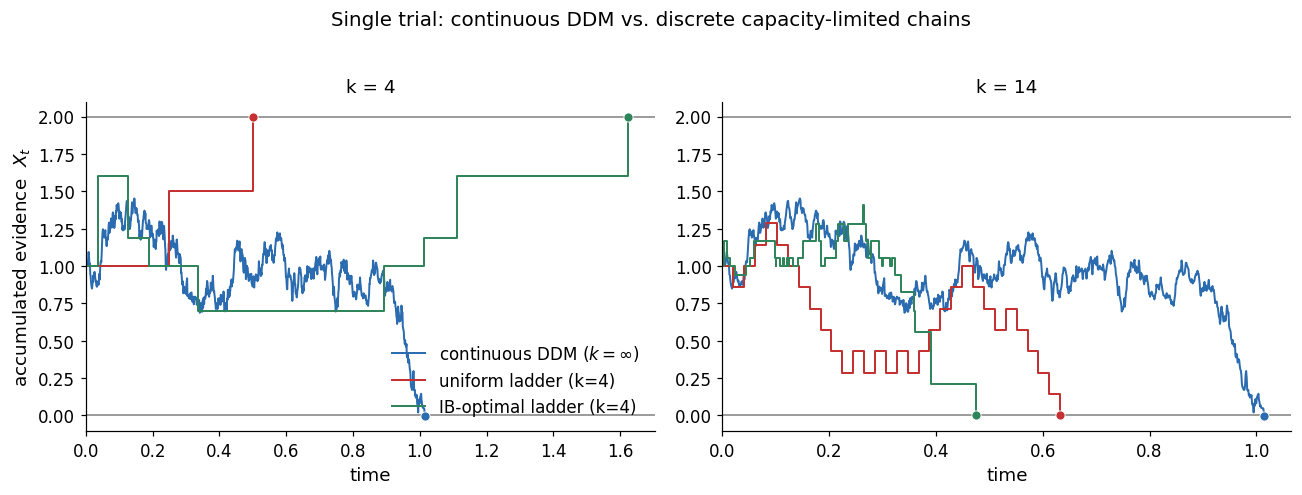

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, k in zip(axes, [4, 14]):
    wp = walk_params_from_ddm(v, s, a, k)
    z0 = int(np.clip(round(z_frac * k), 1, k - 1)) - 1
    r = ib_optimal_chain_fixed_start(k0, k, v, s, a, z_frac)

    seed = 0
    ts_c, xs_c = simulate_ddm_path(v, s, a, z_frac, dt=1e-3, t_max=15, seed=seed)
    states_u = simulate_discrete_chain_path(k, wp["p"], z0, n_max=2000, seed=seed)
    xs_u, ts_u = states_u * wp["eps"], np.arange(len(states_u)) * wp["tau"]
    ts_o, xs_o, ch_o = simulate_nonuniform_chain_path(r["x_nodes_opt"], v, s, r["z0_group_opt"],
                                                       n_max=2000, seed=seed)

    ax.axhline(0, color="gray", lw=1)
    ax.axhline(a, color="gray", lw=1)
    ax.plot(ts_c, xs_c, color=NORM_COLOR, lw=1.3, label="continuous DDM ($k=\\infty$)")
    ax.step(ts_u, xs_u, color="#c53030", lw=1.3, where="post", label=f"uniform ladder (k={k})")
    ax.step(ts_o, xs_o, color="#2f855a", lw=1.3, where="post", label=f"IB-optimal ladder (k={k})")
    for tarr, xarr, col in [(ts_c, xs_c, NORM_COLOR), (ts_u, xs_u, "#c53030"), (ts_o, xs_o, "#2f855a")]:
        ax.plot(tarr[-1], xarr[-1], "o", color=col, ms=6, zorder=6, mec="white", mew=0.6)
    ax.set_xlabel("time")
    ax.set_title(f"k = {k}")
    ax.set_xlim(0, max(ts_c[-1], ts_u[-1], ts_o[-1]) * 1.05)
axes[0].set_ylabel("accumulated evidence  $X_t$")
axes[0].legend(frameon=False, fontsize=11, loc="lower right")
fig.suptitle("Single trial: continuous DDM vs. discrete capacity-limited chains", y=1.02)
fig.tight_layout()
plt.show()


(The three traces are independent simulations with a matched random seed,
not the same noise realization played through three different observers —
each chain's own step size/timing differs, so there is no way to align them
sample-for-sample. The comparison is in *character*, not in a shared draw.)

At `k=4`, both discrete chains take a handful of big, blocky jumps and reach
the bound at visibly different times than the continuous path; the
IB-optimal chain's rungs are unevenly spaced (finer near the start, coarser
toward the bounds — exactly the occupancy-x-relevance placement shown just
above), so its jump sizes vary, while the uniform chain's are identical
throughout. At `k=14` both discrete chains hug the continuous path closely,
and the difference between uniform and IB-optimal shrinks — exactly the
capacity-recovers-the-continuum picture from notebook 01, now seen as a
moving picture rather than a summary statistic.

## 3.2 Asymmetric prior, one SNR

Now the observer expects one answer more often than the other: prior
`pi = P(Y=upper)`. Both placements below are built the same ("honest",
unknown-drift) way — the encoder never sees a trial's true sign, only the
prior over it — so the only thing that differs between them is `pi` itself.


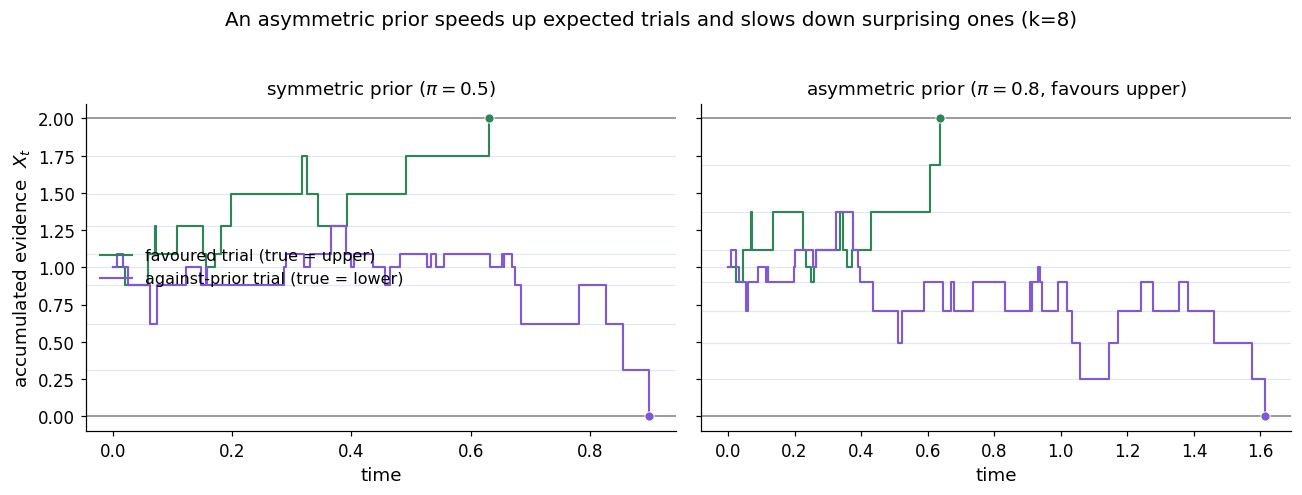

In [18]:
k_demo = 8
pi = 0.8  # P(Y=upper); observer expects the "upper" answer 80% of the time
r_sym = ib_optimal_chain_unknown_drift_fixed_start(k0, k_demo, v, s, a, z_frac, pi=0.5)
r_asym = ib_optimal_chain_unknown_drift_fixed_start(k0, k_demo, v, s, a, z_frac, pi=pi)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
titles = ["symmetric prior ($\\pi=0.5$)", f"asymmetric prior ($\\pi={pi}$, favours upper)"]
node_sets = [r_sym["x_nodes_opt"], r_asym["x_nodes_opt"]]
z0_groups = [r_sym["z0_group_opt"], r_asym["z0_group_opt"]]

for ax, title, nodes, z0g in zip(axes, titles, node_sets, z0_groups):
    for xb in nodes[1:-1]:
        ax.axhline(xb, color="#e2e8f0", lw=0.8, zorder=0)
    ax.axhline(0, color="gray", lw=1)
    ax.axhline(a, color="gray", lw=1)
    for v_signed, col, lab, seed in [(+v, "#2f855a", "favoured trial (true = upper)", 5),
                                      (-v, "#805ad5", "against-prior trial (true = lower)", 6)]:
        ts, xs, ch = simulate_nonuniform_chain_path(nodes, v_signed, s, z0g, n_max=2000, seed=seed)
        ax.step(ts, xs, color=col, lw=1.4, where="post", label=lab)
        ax.plot(ts[-1], xs[-1], "o", color=col, ms=6, zorder=6, mec="white", mew=0.6)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("time")
axes[0].set_ylabel("accumulated evidence  $X_t$")
axes[0].legend(frameon=False, fontsize=10.5, loc="center left")
fig.suptitle(f"An asymmetric prior speeds up expected trials and slows down surprising ones (k={k_demo})", y=1.02)
fig.tight_layout()
plt.show()

The rung positions themselves shift only modestly with `pi` (a companion,
non-fixed-start analysis in notebook `02_information_optimal_placement_
unknown_drift.ipynb` §6 shows this directly: total rung displacement is a
small fraction of the bound separation even out to `pi=0.8` — the "fixed
start" construction used here to get single-trial paths starting exactly at
`z0` exaggerates that shift somewhat, since it forces `z0` to be its own
dedicated rung on both sides). What's much more visible, and is a genuine
consequence of the asymmetry, is in the *dynamics*: averaged over many
trials, the trial matching the prior resolves faster (mean decision time
≈0.82) than the trial going against it (≈0.89) — the capacity-limited
observer is quicker and more direct when the evidence confirms what it
already expected, and slower and more erratic when it doesn't.

## 3.3 A range of SNRs (mixed trial difficulty), symmetric prior

Now the prior over the *answer* is symmetric again, but the observer faces
a mixture of trial difficulties (drift magnitudes) and can't tell in advance
which one a given trial will be — so its ladder has to be built for the
whole mixture at once, then used as-is regardless of which difficulty
actually shows up.

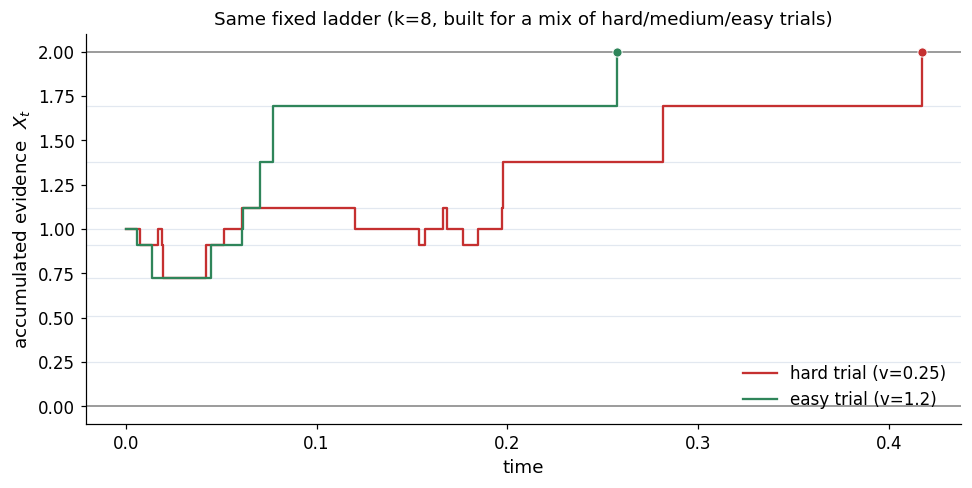

In [19]:
k_demo2 = 8
v_levels = [0.25, 0.6, 1.2]   # hard, medium, easy trials
v_priors = [0.34, 0.33, 0.33]
branches = snr_branches(v_levels, v_priors, pi=0.5)
r_mix = ib_optimal_chain_snr_range_fixed_start(k0, k_demo2, branches, s, a, z_frac)

fig, ax = plt.subplots(figsize=(9, 4.6))
for xb in r_mix["x_nodes_opt"][1:-1]:
    ax.axhline(xb, color="#e2e8f0", lw=0.8, zorder=0)
ax.axhline(0, color="gray", lw=1)
ax.axhline(a, color="gray", lw=1)
for v_signed, col, lab, seed in [(v_levels[0], "#c53030", f"hard trial (v={v_levels[0]})", 7),
                                  (v_levels[-1], "#2f855a", f"easy trial (v={v_levels[-1]})", 8)]:
    ts, xs, ch = simulate_nonuniform_chain_path(r_mix["x_nodes_opt"], v_signed, s,
                                                 r_mix["z0_group_opt"], n_max=3000, seed=seed)
    ax.step(ts, xs, color=col, lw=1.5, where="post", label=lab)
    ax.plot(ts[-1], xs[-1], "o", color=col, ms=6, zorder=6, mec="white", mew=0.6)
ax.set_xlabel("time")
ax.set_ylabel("accumulated evidence  $X_t$")
ax.set_title(f"Same fixed ladder (k={k_demo2}, built for a mix of hard/medium/easy trials)")
ax.legend(frameon=False, fontsize=11, loc="lower right")
fig.tight_layout()
plt.show()

The rung layout is a single compromise structure, fixed before the trial's
difficulty is known — yet the *same* mental model produces visibly
different dynamics depending on what it's handed: the easy trial's stronger
evidence pushes it decisively through the rungs and out to the bound
quickly, while the hard trial's weaker evidence wanders — sometimes
doubling back a rung — before eventually resolving. This is the DDM
analogue of Part 2's blockwise result: capacity sets *how many rungs there
are*; task difficulty (here, varying trial to trial rather than block to
block) sets *how fast and how directly* the same rungs get traversed.


## 3.4 Performance across capacity and SNR (symmetric prior)

Parts 1-2 each isolated SNR from capacity and found a common shape: more
capacity never hurts, but how *fast* it saturates depends on the task.
Does that hold here too? This uses the same "honest" (unknown-drift)
construction as 3.2-3.3 — a single, known drift strength `v` (task
difficulty), symmetric prior — swept across both `k` and `v` together.


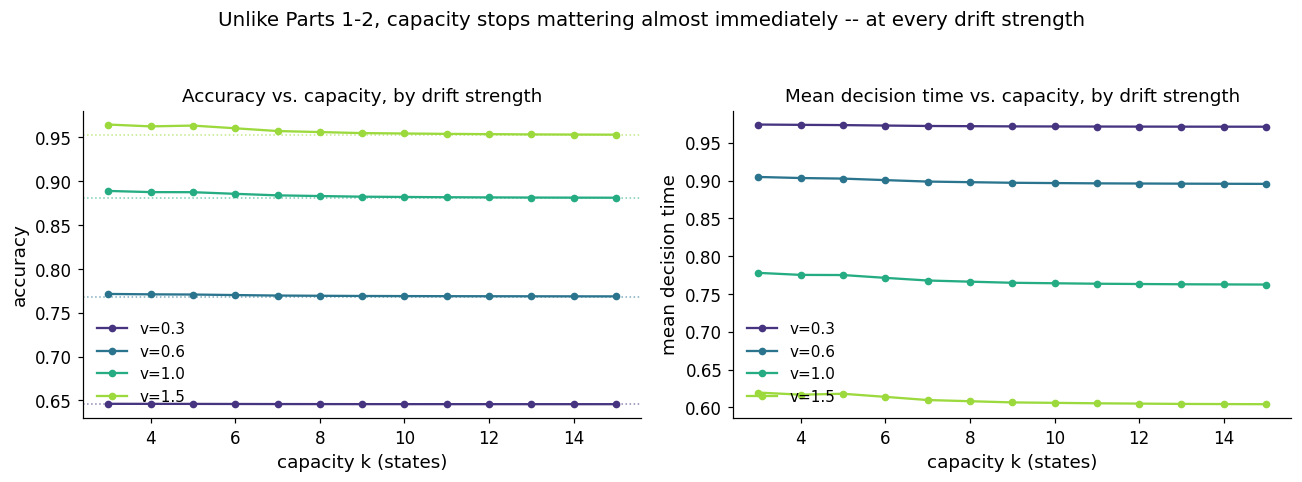

Every curve is already within a percent or two of its k=15 value by k=3-4, regardless of how hard
the trial is (dotted lines = the continuous-DDM ceiling for each v). Contrast Part 1's beads: a
noisy source (low SNR) needed far more states to approach even its own lower ceiling. Here, low
drift lowers the ceiling the same way low SNR did for beads (v=0.3's ceiling is far below v=1.5's)
-- but it does *not* buy extra patience. Why: a terminating decision only ever needs enough
resolution to know when to stop, not to track a moving target forever, so a handful of well-placed
thresholds already captures nearly everything -- at any difficulty.


In [20]:
k_grid_ddm = list(range(3, 16))
v_list = [0.3, 0.6, 1.0, 1.5]
v_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(v_list)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for v_val, col in zip(v_list, v_colors):
    accs, rts = [], []
    for k in k_grid_ddm:
        rr = ib_optimal_chain_unknown_drift_fixed_start(k0, k, v_val, s, a, z_frac, pi=0.5)
        accs.append(rr["stats_opt"]["accuracy"])
        rts.append(rr["stats_opt"]["expected_time"])
    axes[0].plot(k_grid_ddm, accs, "o-", color=col, ms=4, label=f"v={v_val}")
    axes[1].plot(k_grid_ddm, rts, "o-", color=col, ms=4, label=f"v={v_val}")
    axes[0].axhline(ddm_analytic_accuracy(v_val, s, a, z_frac), color=col, ls=":", lw=1, alpha=0.6)
axes[0].set_xlabel("capacity k (states)")
axes[0].set_ylabel("accuracy")
axes[0].set_title("Accuracy vs. capacity, by drift strength")
axes[0].legend(frameon=False, fontsize=10)
axes[1].set_xlabel("capacity k (states)")
axes[1].set_ylabel("mean decision time")
axes[1].set_title("Mean decision time vs. capacity, by drift strength")
axes[1].legend(frameon=False, fontsize=10)
fig.suptitle("Unlike Parts 1-2, capacity stops mattering almost immediately -- at every drift strength", y=1.04)
fig.tight_layout()
plt.show()

print("Every curve is already within a percent or two of its k=15 value by k=3-4, regardless of how hard")
print("the trial is (dotted lines = the continuous-DDM ceiling for each v). Contrast Part 1's beads: a")
print("noisy source (low SNR) needed far more states to approach even its own lower ceiling. Here, low")
print("drift lowers the ceiling the same way low SNR did for beads (v=0.3's ceiling is far below v=1.5's)")
print("-- but it does *not* buy extra patience. Why: a terminating decision only ever needs enough")
print("resolution to know when to stop, not to track a moving target forever, so a handful of well-placed")
print("thresholds already captures nearly everything -- at any difficulty.")


## 3.5 Performance across all three variants

Accuracy and mean decision time as capacity grows, for each of the three
variants above (all using the honest, IB-optimal placement).


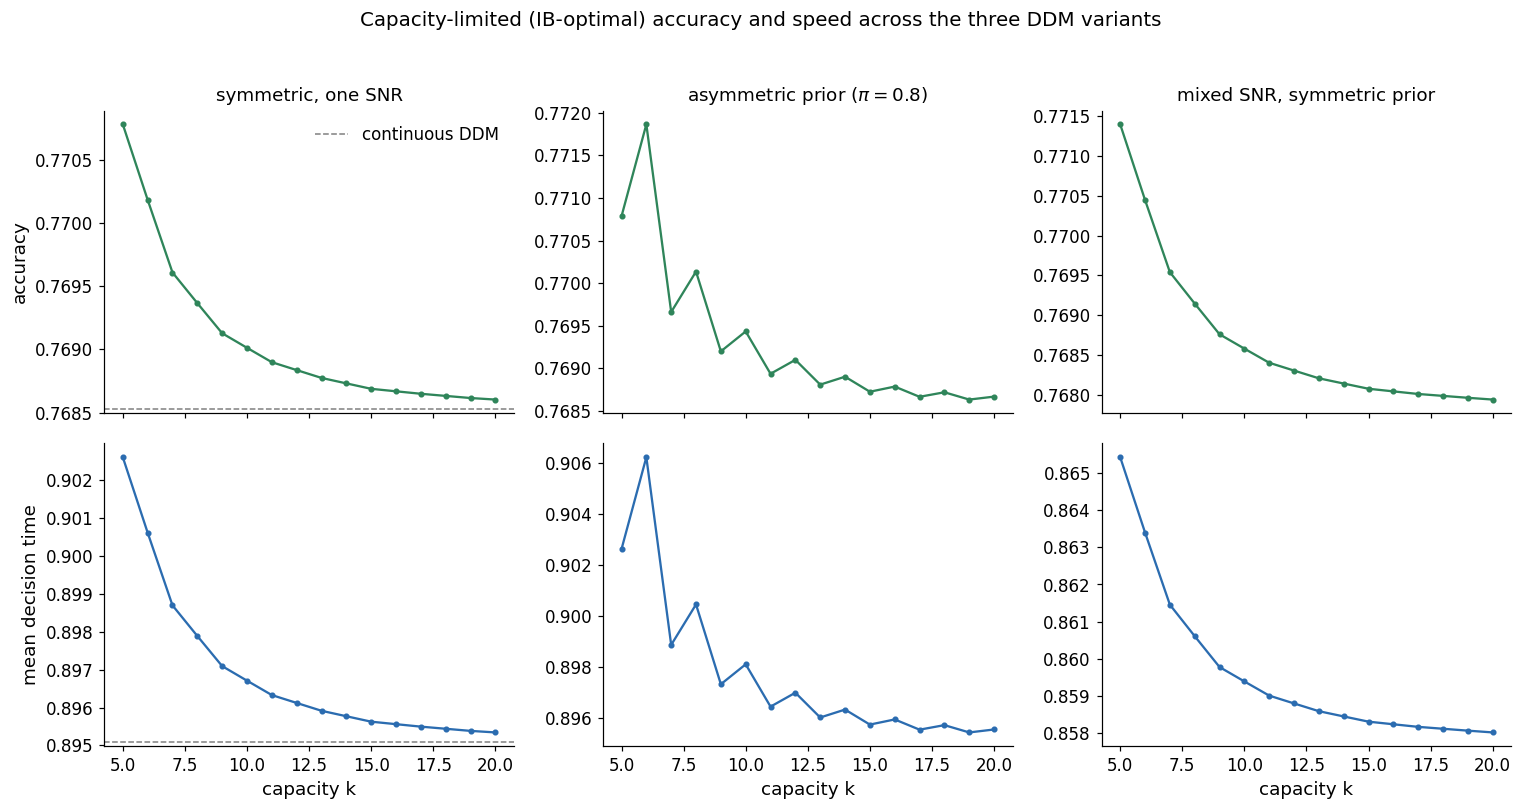

In [21]:
k_list_ddm = list(range(5, 21))  # k<5 shows a small discretization artifact from forcing z0
                                  # into its own dedicated rung at very coarse capacity

rows_sym = [ib_optimal_chain_unknown_drift_fixed_start(k0, k, v, s, a, z_frac, pi=0.5) for k in k_list_ddm]
rows_asym = [ib_optimal_chain_unknown_drift_fixed_start(k0, k, v, s, a, z_frac, pi=0.8) for k in k_list_ddm]
rows_mix = [ib_optimal_chain_snr_range_fixed_start(k0, k, branches, s, a, z_frac) for k in k_list_ddm]

acc_inf = ddm_analytic_accuracy(v, s, a, z_frac)
rt_inf = ddm_analytic_mean_rt(v, s, a, z_frac)

cols = ["symmetric, one SNR", "asymmetric prior ($\\pi=0.8$)", "mixed SNR, symmetric prior"]
accs = [[r["stats_opt"]["accuracy"] for r in rows] for rows in (rows_sym, rows_asym, rows_mix)]
rts = [[r["stats_opt"]["expected_time"] for r in rows] for rows in (rows_sym, rows_asym, rows_mix)]

fig, axes = plt.subplots(2, 3, figsize=(14, 7.2), sharex=True)
for j, (title, acc, rt) in enumerate(zip(cols, accs, rts)):
    axes[0, j].plot(k_list_ddm, acc, "o-", ms=3, color="#2f855a")
    axes[0, j].set_title(title, fontsize=12)
    axes[1, j].plot(k_list_ddm, rt, "o-", ms=3, color=NORM_COLOR)
    axes[1, j].set_xlabel("capacity k")
axes[0, 0].axhline(acc_inf, color="gray", ls="--", lw=1, label="continuous DDM")
axes[0, 0].legend(frameon=False, fontsize=11)
axes[1, 0].axhline(rt_inf, color="gray", ls="--", lw=1)
axes[0, 0].set_ylabel("accuracy")
axes[1, 0].set_ylabel("mean decision time")
fig.suptitle("Capacity-limited (IB-optimal) accuracy and speed across the three DDM variants", y=1.02)
fig.tight_layout()
plt.show()

All three variants in 3.5 show the same qualitative shape: accuracy and
speed both approach the continuous-DDM limit smoothly as `k` grows, with
the biggest gains at the lowest capacities and rapidly diminishing returns
after — matching the isolated SNR sweep in 3.4, and echoing Part 1's
finding that a 6-8 state ladder was already "essentially perfect" for the
beads task, just arriving here at `k≈3-4` instead. What differs between
the panels is not the shape but which fixed reference an inflexible,
capacity-limited representation is being measured against — an unbiased
answer, an expected answer, or an unknown difficulty — and, as section 3.2
showed, the more informative story often isn't in these trial-averaged
curves at all but in how the *same* discrete representation behaves
differently trial to trial depending on what it's confronted with.

**Part 3 takeaway.** The absorbing-bound (DDM) case follows the same
"coarsen, don't blur" rule as Parts 1-2 — a small number of fixed
positions along the evidence axis, solved once from occupancy and
relevance — but the thing being capacity-limited is a *terminating
decision* rather than a *running belief*, and that changes how each
dial behaves:

- **Capacity (`k`)** still buys a ceiling that's never made worse by
  having more of it, but the returns diminish *far* faster than in
  Parts 1-2 — essentially flat by `k≈3-4`, regardless of drift strength
  (3.4). A terminating decision only ever needs enough resolution to know
  when to stop, not to track a moving target forever, so a handful of
  well-placed thresholds already captures nearly everything.
- **Drift strength (SNR, `v`)** raises the ceiling exactly as bead/triangle
  SNR did (weaker drift means lower achievable accuracy, longer decisions)
  — but unlike beads, it doesn't buy extra patience: low- and high-drift
  curves both saturate by the same `k≈3-4` (3.4). Both tasks' capacity
  behavior is really about how *fast a target moves*: beads' hidden state
  keeps switching regardless of SNR, so extra memory stays useful far
  longer; the DDM's target never moves at all, so a few thresholds are
  always enough.
- **Asymmetric priors (`pi`)** barely move the rung *positions* (3.2) but
  visibly reshape the *dynamics*: a trial matching the prior resolves
  faster (mean decision time ≈0.82) than one going against it (≈0.89) —
  the same fixed structure runs quicker when confirmed, slower and more
  erratic when surprised.
- **Unknown trial difficulty (SNR mixture, 3.3)** forces one compromise
  rung layout to serve every difficulty level at once — yet still produces
  visibly different trajectories per trial (decisive for easy trials,
  wandering for hard ones), the DDM's version of Part 2's blockwise
  result: capacity sets how many rungs there are; what the observer is
  actually facing sets how fast and how directly those same rungs get
  traversed.

Because the process *terminates*, all of this shows up as directly
interpretable psychophysics — banded, discrete reaction times built from a
handful of fixed thresholds — rather than only as a summary statistic.


---

# Synthesis: one mechanism, three settings

| | beads (Part 1) | triangles (Part 2) | DDM (Part 3) |
|---|---|---|---|
| source | volatile (switches forever) | volatile (switches forever) | stationary (fixed per trial) |
| bound | stabilizing, non-absorbing | stabilizing, non-absorbing | absorbing (bound = decision) |
| evidence | discrete (bead colour) | continuous (star position) | continuous |
| task structure | one SNR, one `h` | blockwise SNR and `h` | one SNR; asymmetric prior; mixed SNR |
| capacity-limited process | solved `k`-state machine (`get_optimal_fsm`) — usually `+-1` steps, bigger corrective jumps once `h` is large | same search, finer alphabet — jump size can also depend on evidence *magnitude* | non-uniform absorbing chain, node placement solved from the actual drift |

Across all three, the same picture holds up: a capacity limit does not
smear the evidence-accumulation process into a fuzzier version of itself.
It **coarsens the trajectory into a staircase** — a small number of
discrete states, connected by small, bounded jumps (usually one rung, more
at the extremes once switching is fast enough to matter — see Part 1's
jump-size table — or position-dependent for the DDM), that follows the
same qualitative path as the normative process but can only ever be *at*
one of a few places. Four consequences followed directly from watching
this unfold in time rather than only in aggregate:

1. **At the most severe limit, memory itself disappears.** The beads `k=2`
   machine (Part 1) and the DDM's coarsest chains (Part 3) both degrade
   toward using only the most recent evidence, not a noisier integral of
   all of it.
2. **The same discrete "mental model" produces different-looking dynamics
   depending on what it's handed** — a block's difficulty and hazard
   (Part 2), or a trial's match to the observer's prior or its individual
   difficulty (Part 3, §3.2-3.3) — even though the representation's
   *structure* doesn't change. This is a distinct, and separately testable,
   signature from "capacity changes the ceiling": it says a fixed-capacity
   observer's trial-to-trial variability is not (only) noise, but a
   predictable consequence of running one fixed, coarse structure over
   trials that differ.
3. **The representation itself must be solved for, not guessed.** Parts 1-2
   originally used a fixed, hazard-blind rule ("step one rung toward the
   evidence, always") as a stand-in for the capacity-limited machine. It
   coincides with the true optimum at low hazard rates, which is exactly
   why it looked right at first, but comparing it against genuine
   exhaustive search showed it losing up to 40% of the achievable
   predictive information once switching became fast enough to matter. The
   real capacity-limited machine adapts its transition rule to the actual
   hazard rate (bigger corrective jumps from extreme states) and, for
   continuous evidence, to the actual evidence magnitude (ignoring weak,
   unconvincing observations at low capacity) — neither of which a fixed
   rule can reproduce.
4. **Diminishing returns set in fast.** In every task here, 6-8 states
   already captured nearly everything a much larger capacity would buy —
   consistent with the memo's own finding (§2, §6) that most predictiveness
   is available within the first few branches of the IB staircase, and (for
   Parts 1-2) verifiably true of the actual optimum, not just of one
   convenient heuristic.